## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import RobustScaler
from scipy.stats.mstats import winsorize


## Manejo de Outliers

Despues de analizar los outliers en el dataset y su distrubucion, se ha decidido aplicar un enfoque de manejo de outliers mas sofisticado. Tomando en cuenta la naturaleza de los datos.

### Outliers tecnicos [Eliminar]

Con esto confirmacmos que no haya outliers causados por errores en la data de entrada, como precios imposibles, volúmenes negativos o relaciones imposibles entre variables.

```python

In [2]:


def detectar_outliers_tecnicos(df):
    """
    Detecta outliers técnicos (errores de datos) en dataset de criptomonedas
    """
    
    outliers_tecnicos = pd.DataFrame()
    
    # 1. VALORES IMPOSIBLES - PRECIOS
    
    # Precios negativos o cero
    precios_invalidos = df[df['price'] <= 0]
    if len(precios_invalidos) > 0:
        print(f" Encontrados {len(precios_invalidos)} precios <= 0")
        print(precios_invalidos[['price', 'market_cap']].head())
        outliers_tecnicos = pd.concat([outliers_tecnicos, precios_invalidos])
    else:
        print(" No hay precios negativos o cero")
    
    # 2. VALORES IMPOSIBLES - VOLUMEN

    
    # Volumen negativo
    volumen_negativo = df[df['volume'] < 0]
    if len(volumen_negativo) > 0:
        print(f" Encontrados {len(volumen_negativo)} volúmenes negativos")
        outliers_tecnicos = pd.concat([outliers_tecnicos, volumen_negativo])
    else:
        print(" No hay volúmenes negativos")
    
    # 3. RELACIONES IMPOSIBLES
    print("\n3. DETECTANDO RELACIONES IMPOSIBLES:")
    print("-" * 40)
    
    # Volumen mayor que 10x el market cap (sospechoso)
    df_temp = df.copy()
    df_temp['volume_to_mcap_ratio'] = df_temp['volume'] / df_temp['market_cap']
    relaciones_raras = df_temp[df_temp['volume_to_mcap_ratio'] > 10]
    
    if len(relaciones_raras) > 0:
        print(f"  Encontrados {len(relaciones_raras)} casos donde volumen > 10x market cap")
        print("Los primeros 5 casos:")
        print(relaciones_raras[['volume', 'market_cap', 'volume_to_mcap_ratio']].head())
        # Estos son sospechosos pero no necesariamente errores
    else:
        print(" Relaciones volumen/market_cap normales")
    
    # 4. CAMBIOS EXTREMOS IMPOSIBLES
    print("\n4. DETECTANDO CAMBIOS IMPOSIBLES EN PRECIO:")
    print("-" * 47)
    
    # Cambios de precio > 1000% en un día (99.9% seguro que es error)
    cambios_extremos = df[abs(df['price_change_%']) > 1000]
    if len(cambios_extremos) > 0:
        print(f" Encontrados {len(cambios_extremos)} cambios > 1000%")
        print(cambios_extremos[['price_change_%', 'price', 'market_cap']].head())
        outliers_tecnicos = pd.concat([outliers_tecnicos, cambios_extremos])
    else:
        print(" No hay cambios de precio imposibles")
    
    # 5. VALORES FALTANTES O INFINITOS
    print("\n5. DETECTANDO VALORES FALTANTES/INFINITOS:")
    print("-" * 47)
    
    # NaN values
    nan_count = df.isnull().sum()
    if nan_count.sum() > 0:
        print(" Valores faltantes encontrados:")
        print(nan_count[nan_count > 0])
    else:
        print(" No hay valores faltantes")
    
    # Infinite values
    inf_mask = np.isinf(df.select_dtypes(include=[np.number]))
    if inf_mask.any().any():
        print(" Valores infinitos encontrados")
        inf_cols = inf_mask.any()[inf_mask.any()].index.tolist()
        print(f"Columnas con infinitos: {inf_cols}")
    else:
        print(" No hay valores infinitos")
    
    # RESUMEN
    print("\n" + "="*60)
    print("RESUMEN DE OUTLIERS TÉCNICOS")
    print("="*60)
    
    if len(outliers_tecnicos) > 0:
        print(f" Total de outliers técnicos detectados: {len(outliers_tecnicos)}")
        print(f" Porcentaje del dataset: {len(outliers_tecnicos)/len(df)*100:.2f}%")
        print("\nRecomendación: ELIMINAR estos registros")
        
        return outliers_tecnicos.index.unique()
    else:
        print(" No se detectaron outliers técnicos")
        print(" Los datos parecen estar limpios")
        return []



# Cargar tu dataset
df = pd.read_csv(r"C:\Users\sdiaz\Documents\upc\7\machin learning\final\data\eda_data.csv")

# Detectar outliers técnicos
indices_outliers = detectar_outliers_tecnicos(df)



 No hay precios negativos o cero
 No hay volúmenes negativos

3. DETECTANDO RELACIONES IMPOSIBLES:
----------------------------------------
 Relaciones volumen/market_cap normales

4. DETECTANDO CAMBIOS IMPOSIBLES EN PRECIO:
-----------------------------------------------
 No hay cambios de precio imposibles

5. DETECTANDO VALORES FALTANTES/INFINITOS:
-----------------------------------------------
 No hay valores faltantes
 No hay valores infinitos

RESUMEN DE OUTLIERS TÉCNICOS
 No se detectaron outliers técnicos
 Los datos parecen estar limpios


### Outliers de Mercado Extremos (TRANSFORMAR)

### Transformaciones logaritmicas para variables muy asimetricas

Estas son observaciones reales, pero distorsionan el entrenamiento de modelos sensibles a escala.

Especialmente importante en redes neuronales (MLP, LSTM) donde los valores extremos pueden provocar explosión o vanishing gradient.

In [3]:
df_transformado = df.copy()
transformaciones_aplicadas = {}

In [4]:
variables = [
    "price", "market_cap", "volume", "tvl_usd",
    "volume_to_marketcap", "price_change_%",
    "market_cap_trend", "tvl_trend"
]

In [5]:
def analizar_variable(df, col):
    print(f"\nVariable: {col}")
    # Filtrar valores no nulos y positivos (para log)
    serie = df[col].dropna()
    serie_pos = serie[serie >= 0]

    # Calcular skewness original
    skw = skew(serie)
    print(f"Asimetría (skew) original: {skw:.2f}")

    # Plot original
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(serie, bins=50, kde=True, color='steelblue')
    plt.title(f"{col} - Distribución original")

    # Plot log(x+1)
    if (serie_pos > 0).sum() > 0:
        serie_log = np.log1p(serie_pos)
        skw_log = skew(serie_log)
        print(f"Asimetría (skew) log(x+1): {skw_log:.2f}")

        plt.subplot(1, 2, 2)
        sns.histplot(serie_log, bins=50, kde=True, color='orange')
        plt.title(f"{col} - Distribución log(x+1)")
    else:
        print("No se puede aplicar log(x+1): no hay valores positivos.")

    plt.tight_layout()
    plt.show()


Variable: price
Asimetría (skew) original: 1.43
Asimetría (skew) log(x+1): 0.93
Asimetría (skew) log(x+1): 0.93


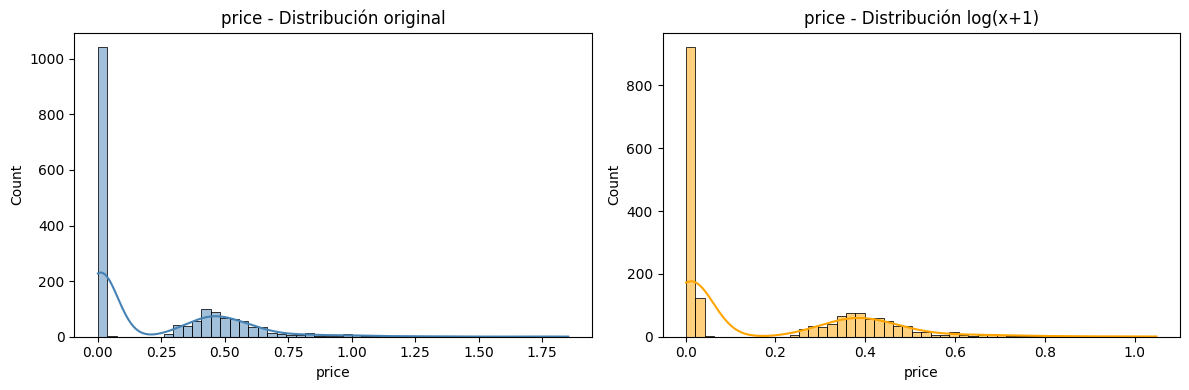


Variable: market_cap
Asimetría (skew) original: 0.93
Asimetría (skew) log(x+1): -0.44


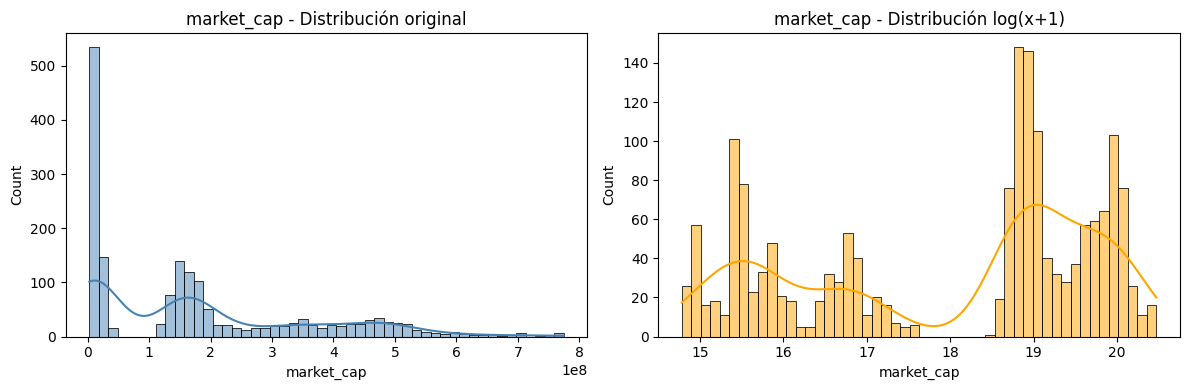


Variable: volume
Asimetría (skew) original: 5.99
Asimetría (skew) log(x+1): -0.51


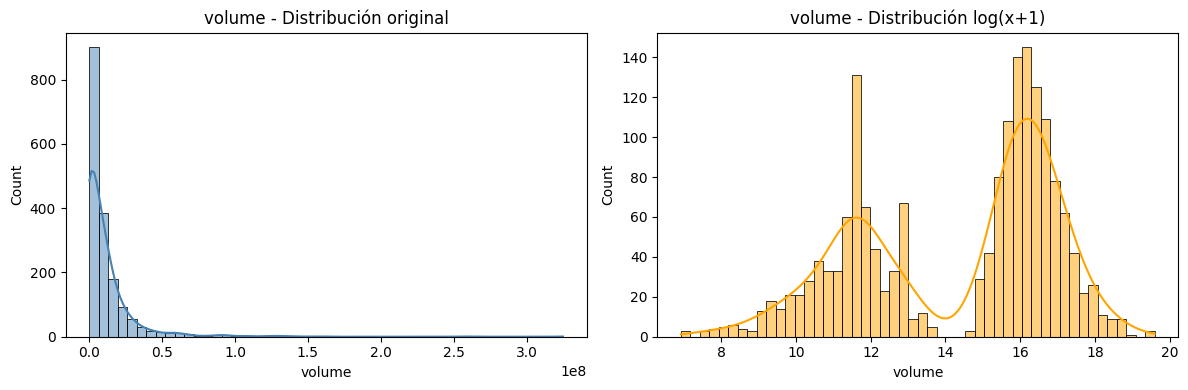


Variable: tvl_usd
Asimetría (skew) original: 1.60
Asimetría (skew) log(x+1): 0.91
Asimetría (skew) log(x+1): 0.91


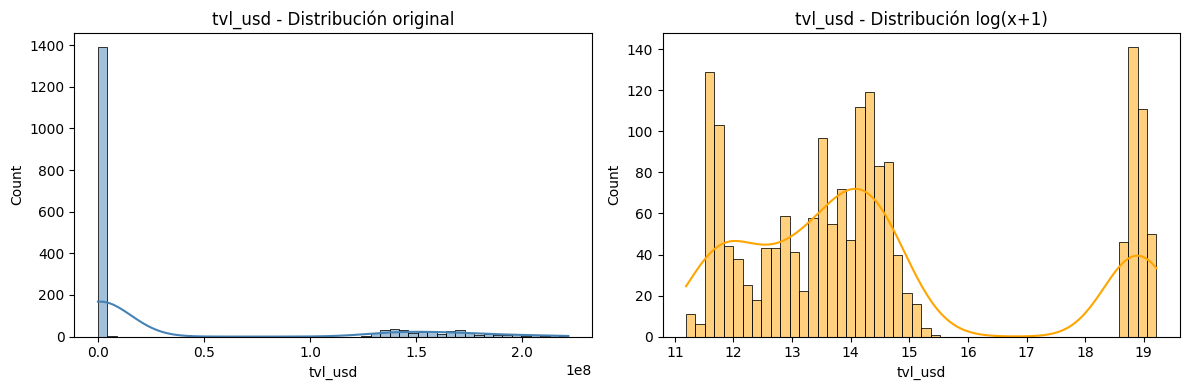


Variable: volume_to_marketcap
Asimetría (skew) original: 4.41
Asimetría (skew) log(x+1): 3.38


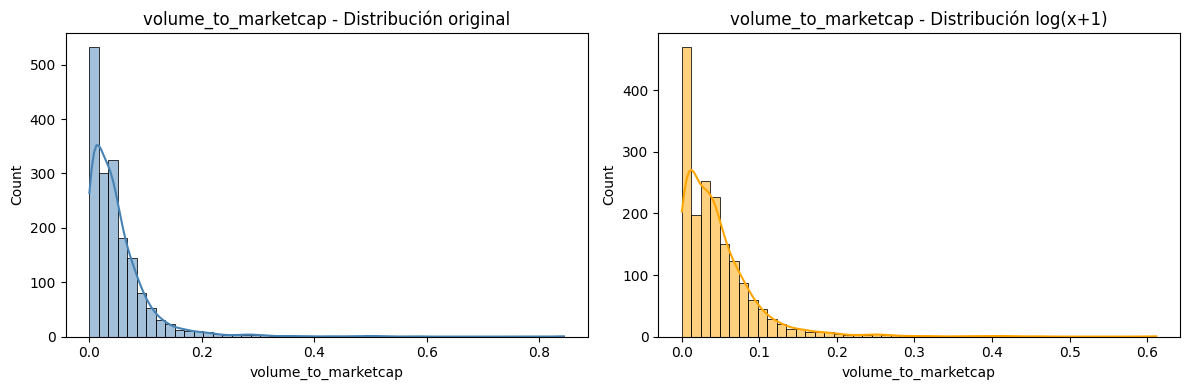


Variable: price_change_%
Asimetría (skew) original: 0.85
Asimetría (skew) log(x+1): 0.27
Asimetría (skew) log(x+1): 0.27


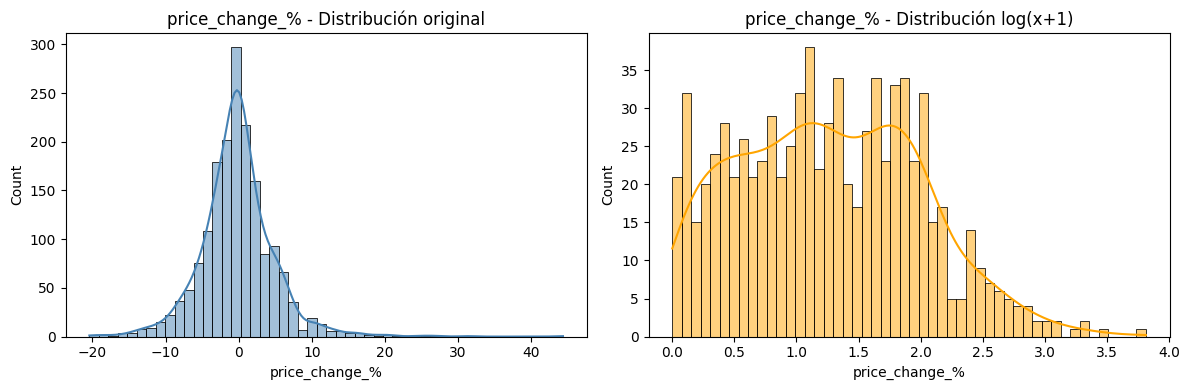


Variable: market_cap_trend
Asimetría (skew) original: 0.87
Asimetría (skew) log(x+1): 0.30
Asimetría (skew) log(x+1): 0.30


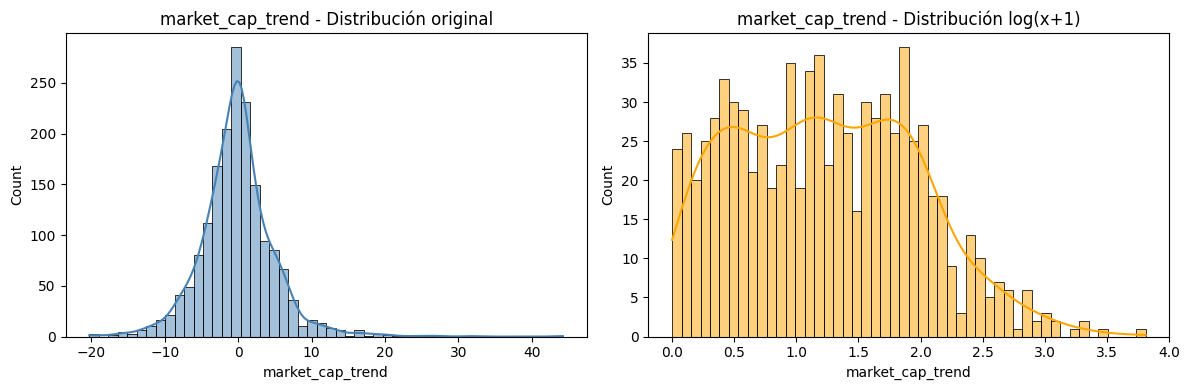


Variable: tvl_trend
Asimetría (skew) original: 8.01
Asimetría (skew) log(x+1): 0.59


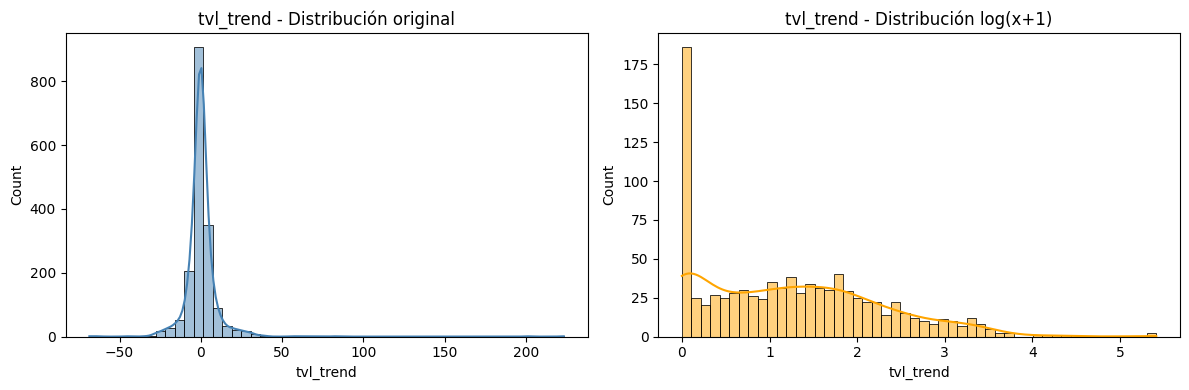

In [6]:
for var in variables:
    if var in df.columns:
        analizar_variable(df, var)
    else:
        print(f"Variable '{var}' no está en el DataFrame.")

In [7]:
df_transformado["price"] = np.log1p(df["price"])
df_transformado["market_cap"] = np.log1p(df["market_cap"])
df_transformado["volume"] = np.log1p(df["volume"])
df_transformado["tvl_usd"] = np.log1p(df["tvl_usd"])

En el contexto de datos financieros de criptoactivos, variables como price, market_cap, volume y tvl_usd presentan distribuciones altamente asimétricas, con valores extremos que distorsionan las métricas estadísticas y el aprendizaje de modelos. La transformación logarítmica (log(x+1)) permite reducir esta asimetría y comprimir la escala de magnitudes, estabilizando la varianza y haciendo que los patrones subyacentes sean más aprendibles para modelos como MLP o LSTM. Aplicar log(x+1) a estas variables mejora su distribución sin eliminar información estructural importante, lo que contribuye a entrenamientos más robustos y generalizables. Esta transformación es especialmente útil cuando se trabaja con datos que cubren órdenes de magnitud distintas entre activos o períodos.

### Winsorización

In [8]:
df_wins = df_transformado.copy()

In [9]:
vars_winsorizar = [
'price', 'market_cap', 'volume', 'tvl_usd',
'volume_to_marketcap', 'price_change_%',
'market_cap_trend', 'tvl_trend'
]

In [10]:

for col in vars_winsorizar:
    if col in df_wins.columns:
        arr = df_wins[col].values
        wins_arr = winsorize(arr, limits=[0.01, 0.01])
        df_wins[col] = wins_arr.data 
    else:
        print(f"{col} no existe en el DataFrame")

In [11]:
def graficar_winsorizacion(df, col, limits=(0.01, 0.01)):
    serie = df[col].dropna().values
    serie_wins = winsorize(serie, limits=limits).data # array limpio
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    # Histograma original
    sns.histplot(serie, bins=50, kde=True, ax=axs[0], color='steelblue')
    axs[0].set_title(f'{col} - Original')

# Histograma winsorizado
    sns.histplot(serie_wins, bins=50, kde=True, ax=axs[1], color='orange')
    axs[1].set_title(f'{col} - Winsorizado')

# Boxplots para comparar
    sns.boxplot(data=[serie, serie_wins], ax=axs[2])
    axs[2].set_xticklabels(['Original', 'Winsorizado'])
    axs[2].set_title(f'{col} - Boxplot')

    plt.tight_layout()
    plt.show()


C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


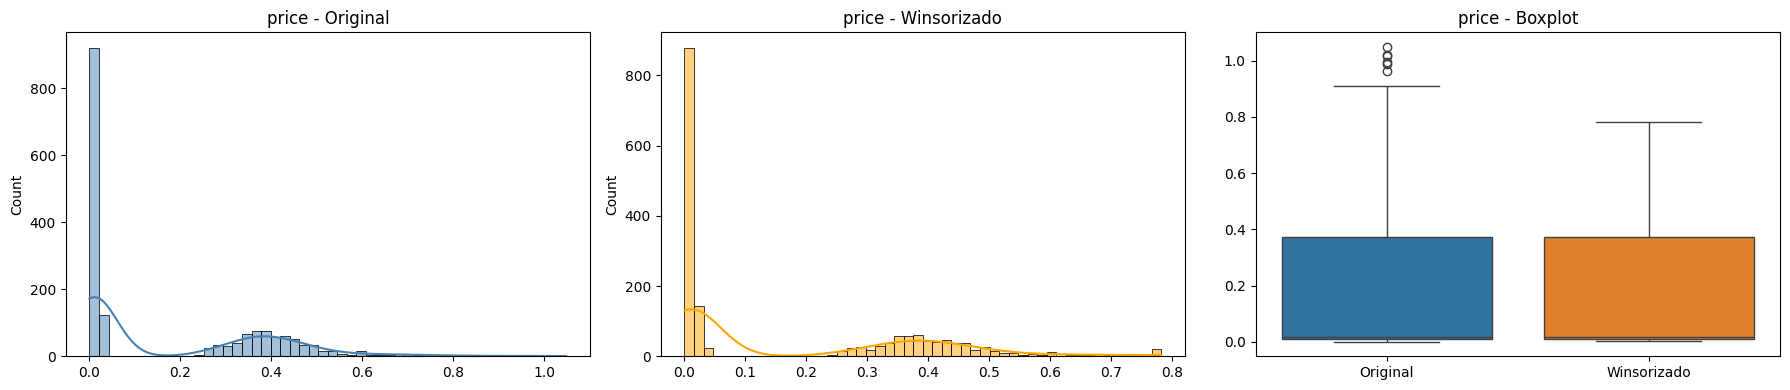

C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


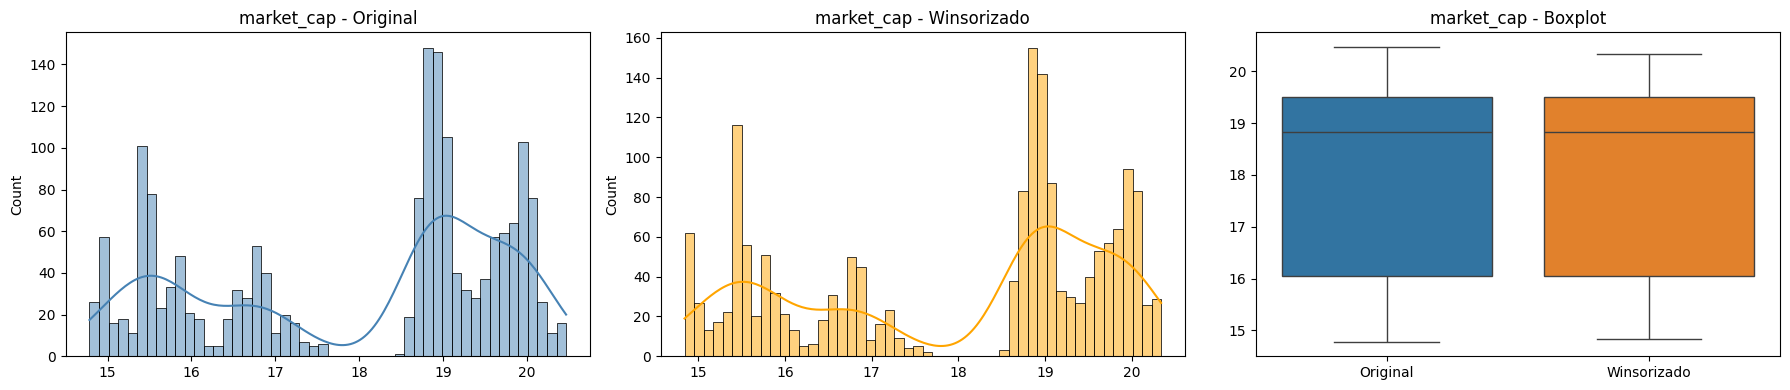

C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


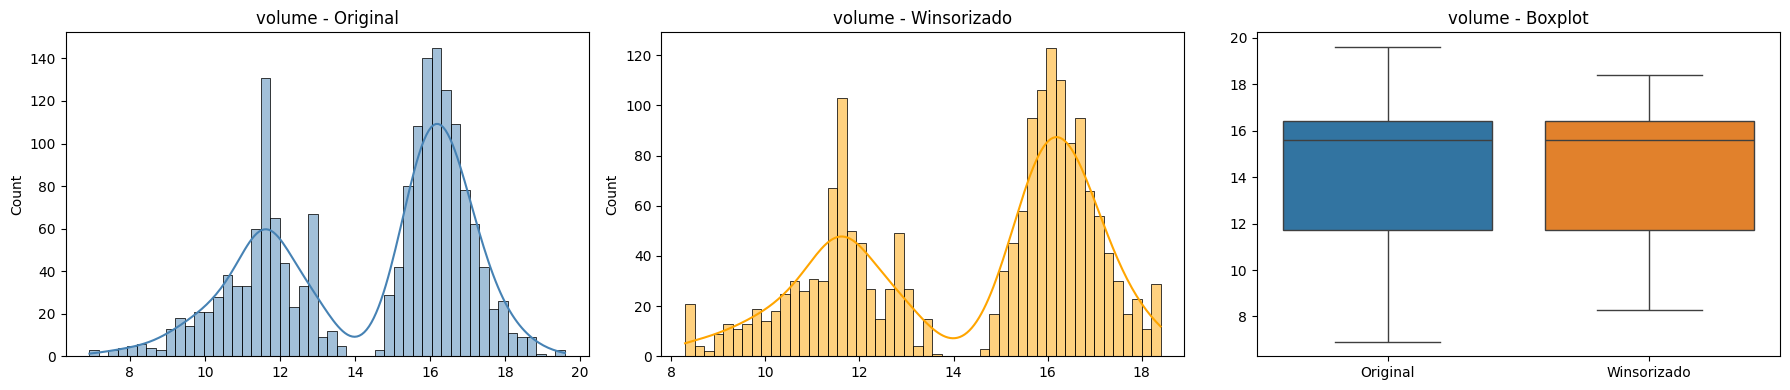

C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


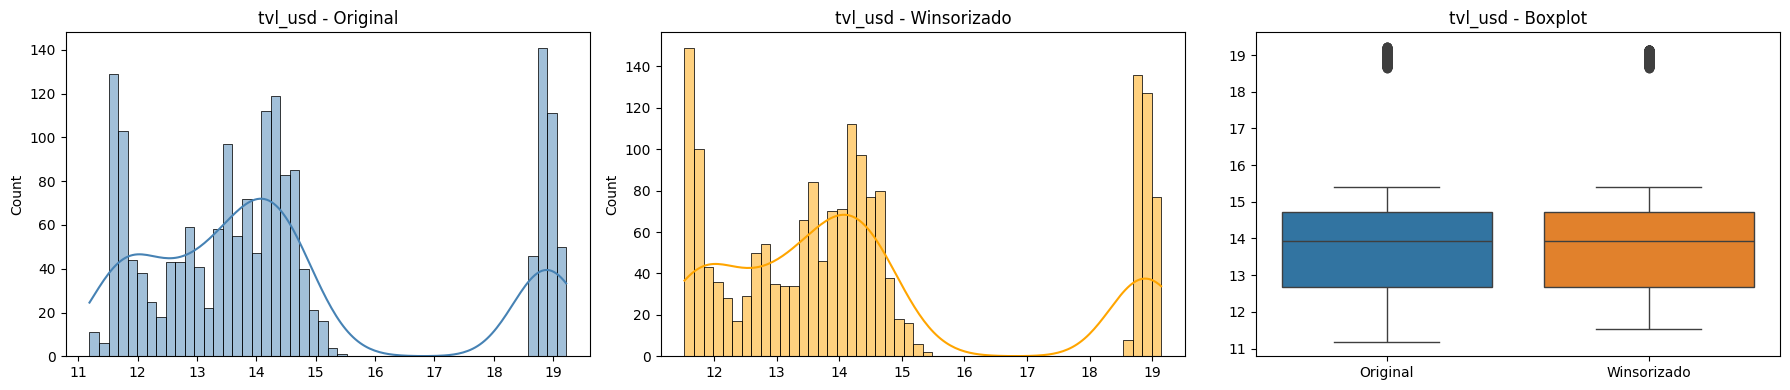

C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


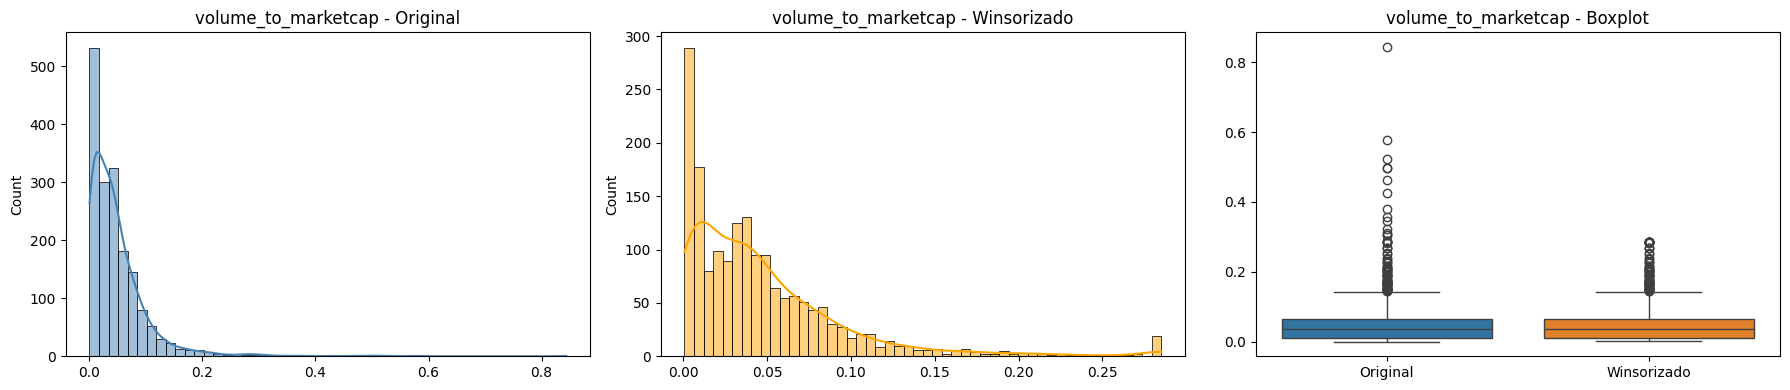

C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


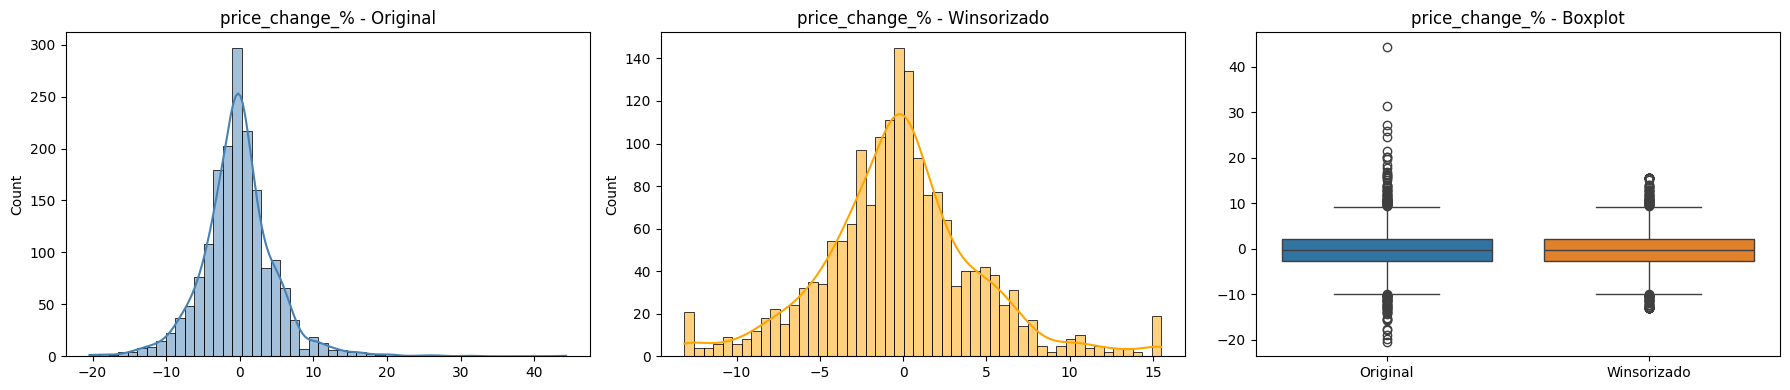

C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


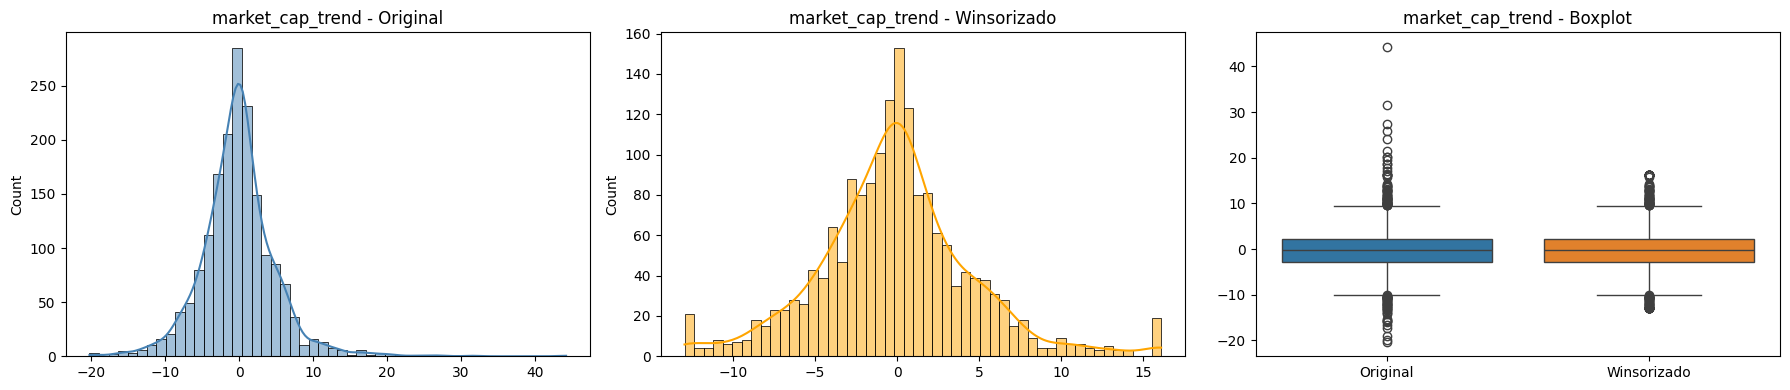

C:\Users\sdiaz\AppData\Local\Temp\ipykernel_6056\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


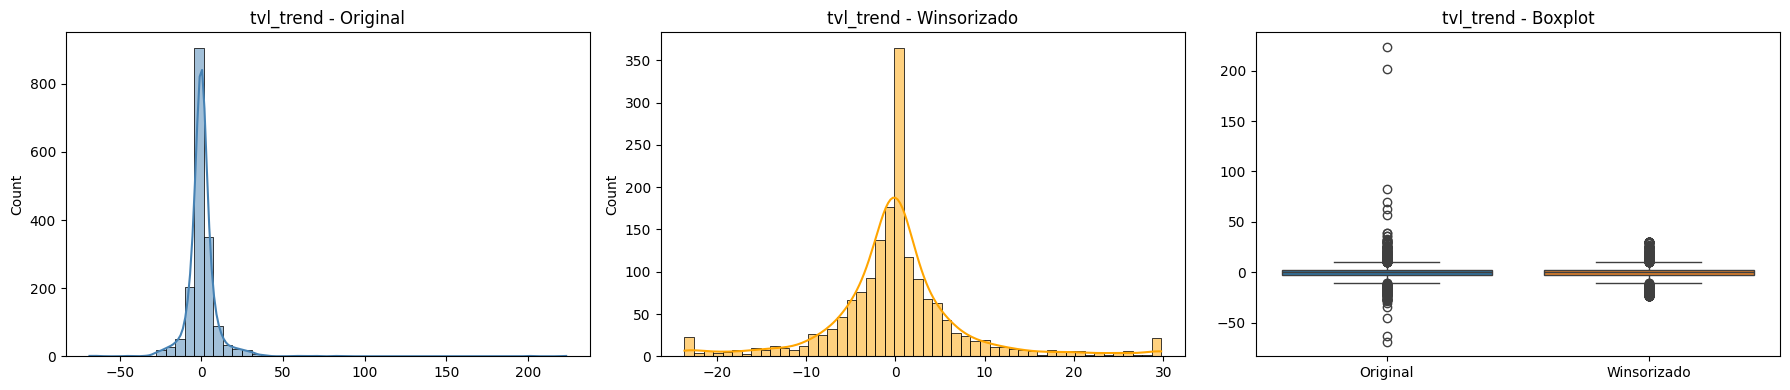

In [12]:
graficar_winsorizacion(df_transformado, 'price')
graficar_winsorizacion(df_transformado, 'market_cap')
graficar_winsorizacion(df_transformado, 'volume')
graficar_winsorizacion(df_transformado, 'tvl_usd')
graficar_winsorizacion(df_transformado, 'volume_to_marketcap')
graficar_winsorizacion(df_transformado, 'price_change_%')
graficar_winsorizacion(df_transformado, 'market_cap_trend')
graficar_winsorizacion(df_transformado, 'tvl_trend')

En contextos financieros como los mercados cripto, es común encontrar valores extremos que representan eventos puntuales o picos abruptos, pero que distorsionan las métricas y afectan la estabilidad de modelos sensibles a escala como redes neuronales. La winsorización limita el impacto de estos valores atípicos recortando los extremos superiores e inferiores a un umbral definido (por ejemplo, percentil 1 y 99), sin eliminar la observación. Esta técnica es útil después de aplicar log(x+1), ya que suaviza aún más la distribución y evita que valores excepcionales dominen el proceso de entrenamiento del modelo.

### Escalacion robusta
En el contexto de criptoactivos, las variables financieras como price, volume y market_cap tienden a presentar distribuciones altamente asimétricas, con valores extremos que reflejan eventos reales del mercado y no necesariamente errores. Si bien se han aplicado transformaciones logarítmicas y winsorización para reducir la distorsión generada por estos valores, aún es necesario un escalado final para estabilizar la magnitud de las variables antes de alimentar modelos como MLP, RNN o LSTM.

RobustScaler resulta una opción especialmente adecuada, ya que escala los datos en función de la mediana y el rango intercuartílico (IQR), lo que permite preservar la jerarquía relativa entre observaciones sin que los outliers dominen la escala. A diferencia de técnicas como StandardScaler o MinMaxScaler, RobustScaler es más resistente a la presencia de valores atípicos y no fuerza a los datos a una distribución simétrica o un rango fijo. Esto permite mantener la estructura estadística del conjunto de datos y, al mismo tiempo, favorecer la estabilidad y eficiencia del proceso de entrenamiento.


In [13]:
scaler = RobustScaler()

In [14]:
df_scaled = df_wins.copy()

In [15]:
scaled_array = scaler.fit_transform(df_scaled[vars_winsorizar])
for i, col in enumerate(vars_winsorizar):
    df_scaled[col] = scaled_array[:, i]

### Creacion de nuevas variables

In [16]:
df_new = df_scaled.copy()

In [17]:
df_new = df_new.sort_values(by=["token", "date"])
df_new["price_volatility"] = df_new.groupby("token")["price"].transform(lambda x: x.pct_change().rolling(window=7, min_periods=1).std())
df_new["price_volatility"] = df_new["price_volatility"].fillna(0)

In [18]:
# Suma simple de señales de impulso
df_new["trend_score"] = (
    df_new["price_change_%"].fillna(0) +
    df_new["market_cap_trend"].fillna(0) +
    df_new["tvl_trend"].fillna(0)
)

In [19]:
df_new['is_healthy'] = (
    (df_new['tvl_trend'].rolling(window=7).mean() > 0) &
    (df_new['market_cap_trend'].rolling(window=7).mean() > 0) &
    (df_new['price_volatility'].rolling(window=7).mean() < 0.2) &
    (df_new['volume_to_marketcap'].rolling(window=7).mean() > 0.01)
).astype(int)

Con el objetivo de enriquecer la representación temporal y estructural de los tokens en el dataset, se han generado tres nuevas variables que capturan aspectos clave del comportamiento financiero de los activos en contextos cripto: volatilidad, impulso de tendencia y señales combinadas de salud.

1. price_volatility
Se define como la desviación estándar móvil de la variación porcentual del precio sobre una ventana de 7 días, calculada por token. Esta métrica estima cuán volátil ha sido el activo en la última semana, proporcionando una señal directa de riesgo o estabilidad. En entornos cripto, donde la variabilidad es común, contar con una medida dinámica de volatilidad permite a los modelos adaptarse mejor a distintos regímenes de mercado.

2. is_healthy
Esta variable binaria representa una etiqueta compuesta que define si un token se encuentra en una condición “saludable”. Se construye evaluando, sobre una ventana móvil de 7 días, cuatro criterios fundamentales: crecimiento sostenido del TVL, crecimiento del market cap, baja volatilidad y una proporción volumen/market cap suficientemente alta. Esta etiqueta puede ser usada tanto como feature como objetivo para tareas de clasificación, y sirve como resumen de comportamiento financiero consistente.

3. trend_score
Esta variable se construye como una suma directa de tres señales de momentum: cambio porcentual de precio, tendencia de capitalización de mercado y tendencia del TVL. Al combinar estas métricas, se obtiene una puntuación continua que indica la dirección y fuerza de los movimientos recientes. Puede ser usada como feature para modelos de predicción o como base para clasificaciones discretas (e.g., activo en tendencia positiva, neutra o negativa).

### Graficos


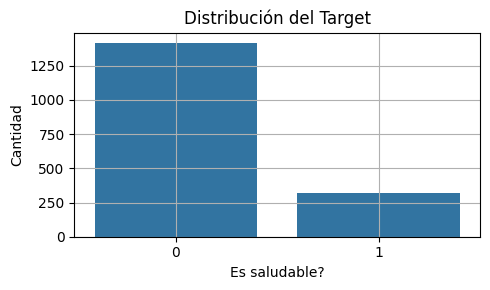

In [20]:
plt.figure(figsize=(5, 3))
sns.countplot(x="is_healthy", data=df_new)
plt.title("Distribución del Target")
plt.xlabel("Es saludable?")
plt.ylabel("Cantidad")
plt.grid(True)
plt.tight_layout()
plt.show()

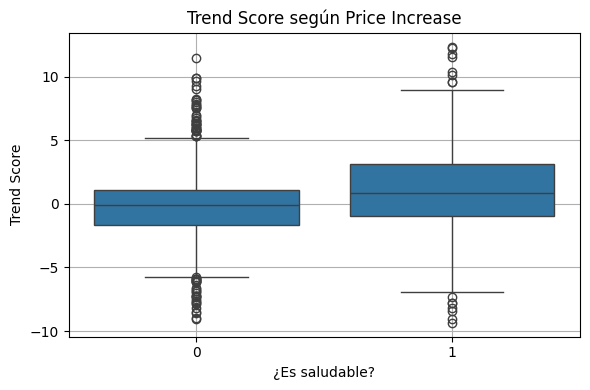

In [21]:
# 2. Trend Score vs Price Increase Label
plt.figure(figsize=(6, 4))
sns.boxplot(x="is_healthy", y="trend_score", data=df_new)
plt.title("Trend Score según Price Increase")
plt.xlabel("¿Es saludable?")
plt.ylabel("Trend Score")
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1740 entries, 696 to 1739
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   date                                     1740 non-null   object 
 1   price                                    1740 non-null   float64
 2   market_cap                               1740 non-null   float64
 3   volume                                   1740 non-null   float64
 4   token                                    1740 non-null   object 
 5   name                                     1740 non-null   object 
 6   tvl_usd                                  1740 non-null   float64
 7   volume_to_marketcap                      1740 non-null   float64
 8   price_change_%                           1740 non-null   float64
 9   market_cap_trend                         1740 non-null   float64
 10  tvl_trend                                1740 non-n

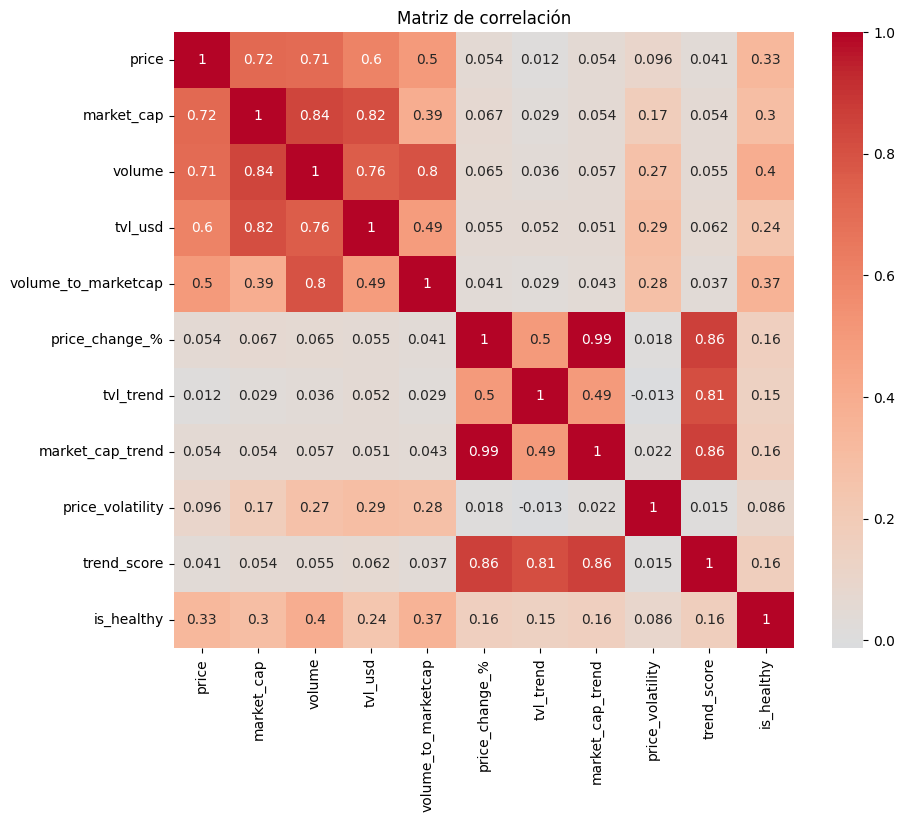

In [23]:
# 3. Volatilidad vs Price Increase Label
cols_heatmap = [
'price', 'market_cap', 'volume', 'tvl_usd',
'volume_to_marketcap', 'price_change_%',
'tvl_trend', 'market_cap_trend',
'price_volatility', 'trend_score', 'is_healthy'
]

corr_matrix = df_new[cols_heatmap].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

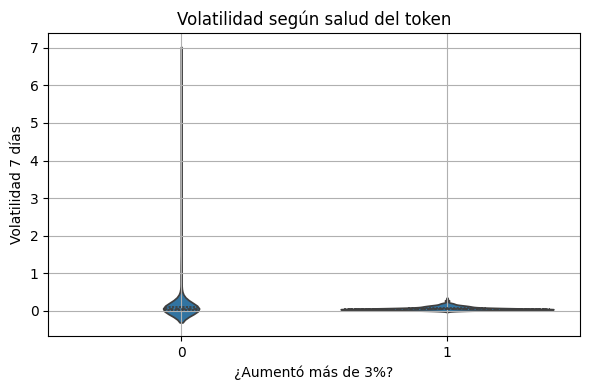

In [24]:
plt.figure(figsize=(6, 4))
sns.violinplot(x="is_healthy", y="price_volatility", data=df_new, inner="quartile")
plt.title("Volatilidad según salud del token")
plt.xlabel("¿Aumentó más de 3%?")
plt.ylabel("Volatilidad 7 días")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:

numeric_columns = df_new.select_dtypes(include='number').columns

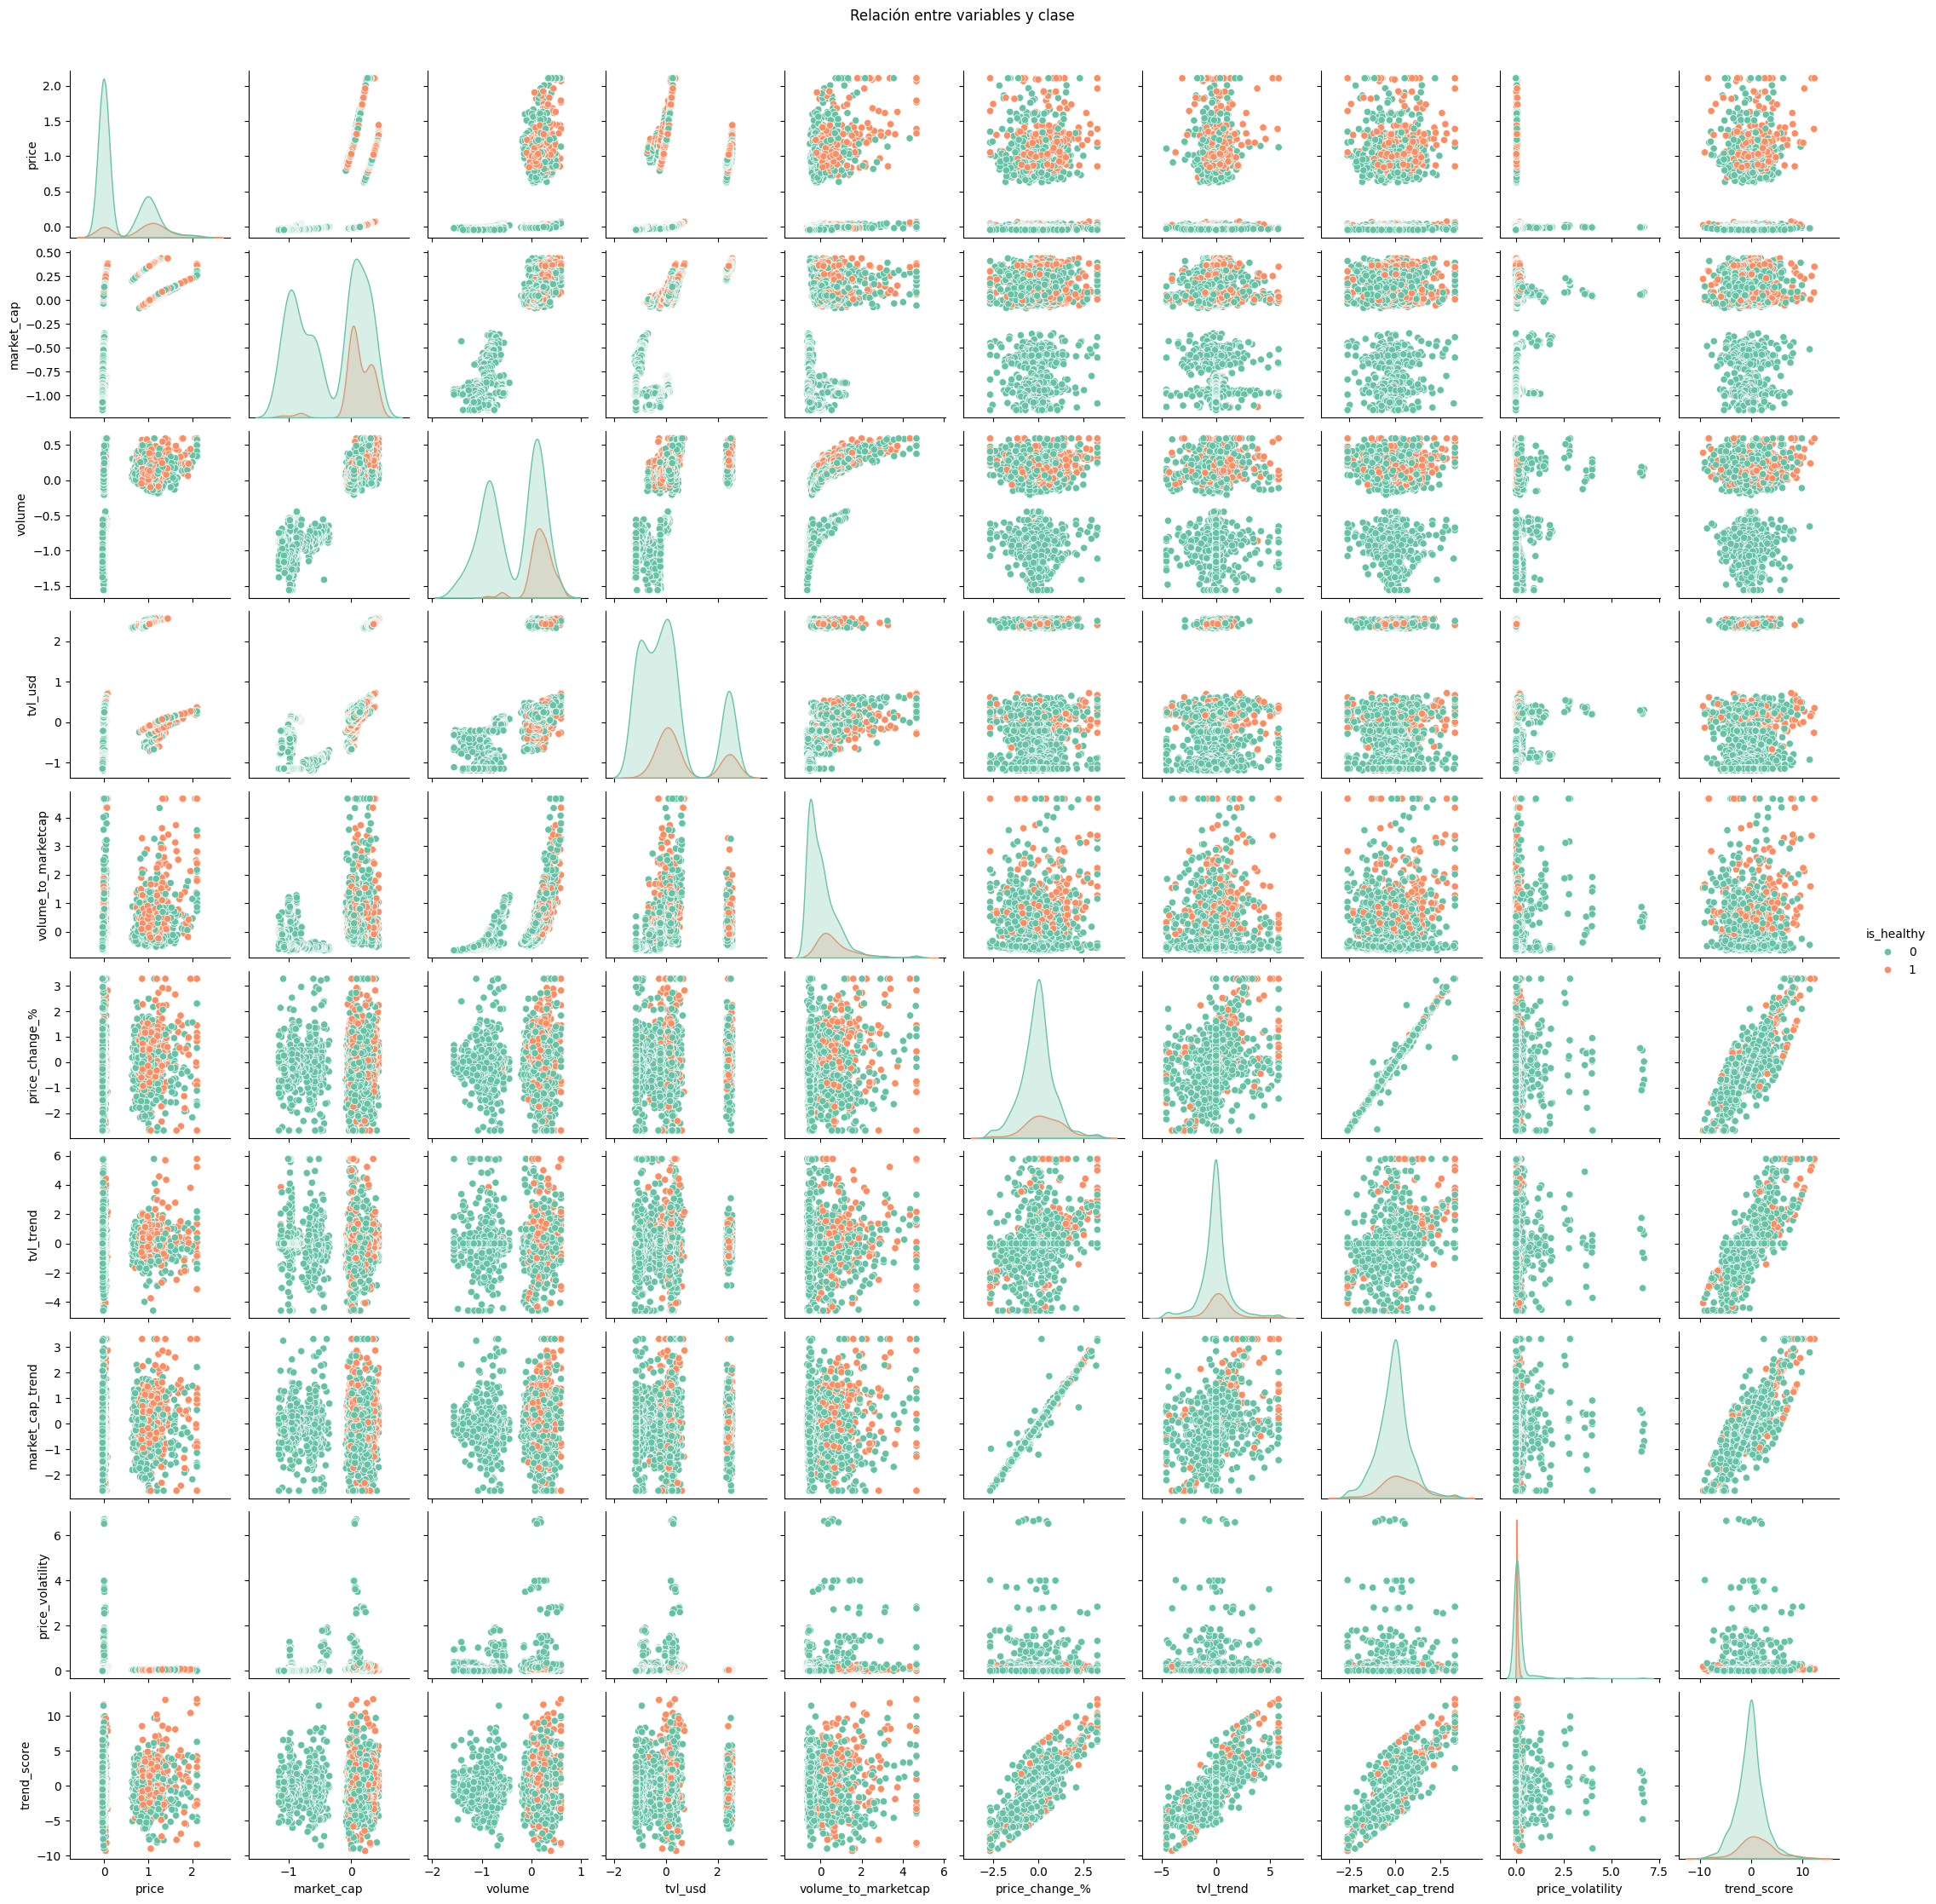

In [26]:
numeric_columns = [
'price', 'market_cap', 'volume', 'tvl_usd',
'volume_to_marketcap', 'price_change_%',
'tvl_trend', 'market_cap_trend',
'price_volatility', 'trend_score',
]

sns.pairplot(
    df_new,
    vars=numeric_columns,
    hue="is_healthy",
    palette="Set2",
    height=2.2
)
plt.suptitle("Relación entre variables y clase", y=1.02)
plt.show()

## VIF y Selección de Características

In [27]:
df_new = df_new.drop(columns=['year', 'month', 'quarter', 'month_name'])

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [29]:
vif_trend_scores = df_new.select_dtypes(include='number').copy()
vif_trend_scores.drop(columns=["is_healthy","price_change_%","market_cap_trend","tvl_trend"],inplace=True)

def calculate_vif(X):
    X_const = add_constant(X)
    vif = pd.DataFrame()
    vif["variable"] = X_const.columns
    vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    return vif.sort_values("VIF", ascending=False)

vif_df = calculate_vif(vif_trend_scores)
print(vif_df)

                                   variable        VIF
3                                    volume  23.221533
2                                market_cap  15.482852
5                       volume_to_marketcap   8.768804
0                                     const   5.888681
9   is_seasonal_outlier_volume_to_marketcap   3.154450
8                is_seasonal_outlier_volume   2.356092
4                                   tvl_usd   2.253722
1                                     price   2.159051
6                 is_seasonal_outlier_price   1.297423
10                         price_volatility   1.151251
7            is_seasonal_outlier_market_cap   1.046725
11                              trend_score   1.015306


In [30]:
vif_smooth_columns = df_new.select_dtypes(include='number').copy()
vif_smooth_columns.drop(columns=["is_healthy","trend_score"], inplace=True)

vif_smooth_df = calculate_vif(vif_smooth_columns)
print(vif_smooth_df)

                                   variable        VIF
6                            price_change_%  62.997128
7                          market_cap_trend  62.583477
3                                    volume  23.246970
2                                market_cap  15.500551
5                       volume_to_marketcap   8.795425
0                                     const   5.914758
12  is_seasonal_outlier_volume_to_marketcap   3.155830
11               is_seasonal_outlier_volume   2.360582
4                                   tvl_usd   2.256314
1                                     price   2.159164
9                 is_seasonal_outlier_price   1.299683
8                                 tvl_trend   1.189499
13                         price_volatility   1.151606
10           is_seasonal_outlier_market_cap   1.047112


## Split train/test

In [31]:
def rebuild_derivative_features(df, threshold=3):
    """
    Recalcula features derivadas por token y en orden temporal:
    - price_change_%
    - market_cap_trend
    - tvl_trend
    - trend_score
    - price_volatility (std rolling de pct_change)
    - price_increase_label (target binario)

    Devuelve un nuevo DataFrame con esas columnas.
    """
    df = df.copy()
    df = df.sort_values(by=["token", "date"])

    # Recalcular variaciones porcentuales
    df["price_change_%"] = df.groupby("token")["price"].pct_change() * 100
    df["market_cap_trend"] = df.groupby("token")["market_cap"].pct_change() * 100
    df["tvl_trend"] = df.groupby("token")["tvl_usd"].pct_change() * 100

    # Rellenar NaNs (puedes ajustar esto si prefieres forward fill u otro criterio)
    df["price_change_%"] = df["price_change_%"].fillna(0)
    df["market_cap_trend"] = df["market_cap_trend"].fillna(0)
    df["tvl_trend"] = df["tvl_trend"].fillna(0)

    # Crear trend_score como suma simple de señales
    df["trend_score"] = (
        df["market_cap_trend"] +
        df["tvl_trend"]+
        df["price_change_%"]
    )

    # Volatilidad del precio basada en std de pct_change (rolling de 7)
    df["price_volatility"] = (
        df.groupby("token")["price"]
        .transform(lambda x: x.pct_change().rolling(window=7, min_periods=1).std())
    )
    df["price_volatility"] = df["price_volatility"].fillna(0)

    # Crear la variable objetivo binaria
    df['is_healthy'] = (
    (df['tvl_trend'].rolling(window=7).mean() > 0) &
    (df['market_cap_trend'].rolling(window=7).mean() > 0) &
    (df['price_volatility'].rolling(window=7).mean() < 0.2) &
    (df['volume_to_marketcap'].rolling(window=7).mean() > 0.01)
    ).astype(int)

    return df

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X = df.copy()
X = X.drop(columns=['year', 'month', 'quarter', 'month_name'])
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42, stratify=None)

In [34]:
X_train = rebuild_derivative_features(X_train)
X_test = rebuild_derivative_features(X_test)

In [35]:
def preprocess_data(df, fit_scaler=True, scaler=None):
    """
    Función completa de preprocesamiento que aplica:
    1. Transformaciones logarítmicas
    2. Winsorización 
    3. Escalado robusto
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame a procesar
    fit_scaler : bool, default=True
        Si True, ajusta un nuevo scaler. Si False, usa el scaler proporcionado
    scaler : RobustScaler, default=None
        Scaler pre-entrenado para usar cuando fit_scaler=False
        
    Returns:
    --------
    df_processed : pd.DataFrame
        DataFrame procesado
    scaler : RobustScaler
        Scaler ajustado (para usar en test set)
    """
    
    # Copiar el DataFrame para no modificar el original
    df_processed = df.copy()
    
    # 1. TRANSFORMACIONES LOGARÍTMICAS
    print("Aplicando transformaciones logarítmicas...")
    log_variables = ["price", "market_cap", "volume", "tvl_usd"]
    
    for var in log_variables:
        if var in df_processed.columns:
            df_processed[var] = np.log1p(df_processed[var])
            print(f"  ✓ Transformación log(x+1) aplicada a {var}")
        else:
            print(f"  ⚠ Variable {var} no encontrada en el DataFrame")
    
    # 2. WINSORIZACIÓN
    print("\nAplicando winsorización...")
    vars_winsorizar = [
        'price', 'market_cap', 'volume', 'tvl_usd',
        'volume_to_marketcap', 'price_change_%',
        'market_cap_trend', 'tvl_trend'
    ]
    
    for col in vars_winsorizar:
        if col in df_processed.columns:
            arr = df_processed[col].values
            wins_arr = winsorize(arr, limits=[0.01, 0.01])
            df_processed[col] = wins_arr.data
            print(f"  ✓ Winsorización aplicada a {col}")
        else:
            print(f"  ⚠ Variable {col} no encontrada para winsorización")
    
    # 3. ESCALADO ROBUSTO
    print("\nAplicando escalado robusto...")
    vars_escalar = [
        'price', 'market_cap', 'volume', 'tvl_usd',
        'volume_to_marketcap', 'price_change_%',
        'market_cap_trend', 'tvl_trend'
    ]
    
    # Filtrar solo las variables que existen en el DataFrame
    vars_existentes = [var for var in vars_escalar if var in df_processed.columns]
    
    if vars_existentes:
        if fit_scaler:
            # Crear y ajustar nuevo scaler
            scaler = RobustScaler()
            scaled_array = scaler.fit_transform(df_processed[vars_existentes])
            print("  ✓ Nuevo RobustScaler ajustado")
        else:
            # Usar scaler existente
            if scaler is None:
                raise ValueError("Debe proporcionar un scaler cuando fit_scaler=False")
            scaled_array = scaler.transform(df_processed[vars_existentes])
            print("  ✓ RobustScaler existente aplicado")
        
        # Asignar valores escalados
        for i, col in enumerate(vars_existentes):
            df_processed[col] = scaled_array[:, i]
            print(f"    - {col} escalado")
    else:
        print("   No se encontraron variables para escalar")
    
    print(f"\n Preprocesamiento completado. Shape final: {df_processed.shape}")
    
    return df_processed, scaler

In [36]:
y_train = X_train.pop("is_healthy")
y_test = X_test.pop("is_healthy")

In [37]:


# Aplicar preprocesamiento al conjunto de entrenamiento (ajustar scaler)
X_train_processed, trained_scaler = preprocess_data(X_train, fit_scaler=True)

print("\n" + "-"*40)

# Aplicar preprocesamiento al conjunto de prueba (usar scaler ya entrenado)
X_test_processed, _ = preprocess_data(X_test, fit_scaler=False, scaler=trained_scaler)



Aplicando transformaciones logarítmicas...
  ✓ Transformación log(x+1) aplicada a price
  ✓ Transformación log(x+1) aplicada a market_cap
  ✓ Transformación log(x+1) aplicada a volume
  ✓ Transformación log(x+1) aplicada a tvl_usd

Aplicando winsorización...
  ✓ Winsorización aplicada a price
  ✓ Winsorización aplicada a market_cap
  ✓ Winsorización aplicada a volume
  ✓ Winsorización aplicada a tvl_usd
  ✓ Winsorización aplicada a volume_to_marketcap
  ✓ Winsorización aplicada a price_change_%
  ✓ Winsorización aplicada a market_cap_trend
  ✓ Winsorización aplicada a tvl_trend

Aplicando escalado robusto...
  ✓ Nuevo RobustScaler ajustado
    - price escalado
    - market_cap escalado
    - volume escalado
    - tvl_usd escalado
    - volume_to_marketcap escalado
    - price_change_% escalado
    - market_cap_trend escalado
    - tvl_trend escalado

 Preprocesamiento completado. Shape final: (1392, 17)

----------------------------------------
Aplicando transformaciones logarítmicas..

## PCA Variables correlacion alta

In [38]:
from sklearn.decomposition import PCA
pca_cols = ['price', 'market_cap', 'volume', 'tvl_usd']
pca = PCA(n_components=0.9)  # o lo que cubra >90% varianza
X_train_pca = pca.fit_transform(X_train[pca_cols])
X_test_pca = pca.transform(X_test[pca_cols])

In [39]:
n_comp = X_train_pca.shape[1]
pca_names = [f"pca_{i+1}" for i in range(n_comp)]
df_pca_train = pd.DataFrame(X_train_pca, columns=pca_names, index=X_train.index)
df_pca_test = pd.DataFrame(X_test_pca, columns=pca_names, index=X_test.index)

In [40]:
X_train_wo_correlated = X_train.drop(columns=pca_cols)
X_test_wo_correlated = X_test.drop(columns=pca_cols)

In [41]:
X_train_final = pd.concat([X_train_wo_correlated, df_pca_train], axis=1)
X_test_final = pd.concat([X_test_wo_correlated, df_pca_test], axis=1)

In [42]:
X_train_final.head()

,date,token,name,volume_to_marketcap,price_change_%,market_cap_trend,tvl_trend,is_seasonal_outlier_price,is_seasonal_outlier_market_cap,is_seasonal_outlier_volume,is_seasonal_outlier_volume_to_marketcap,trend_score,price_volatility,pca_1
696,2024-06-01,kava,Kava,0.011458,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,5.637806e+08
697,2024-06-02,kava,Kava,0.009394,0.190726,0.146635,-6.002434,0,0,0,0,-5.665072,0.000000,5.607843e+08
698,2024-06-03,kava,Kava,0.012490,0.206586,0.130319,-1.194566,0,0,0,0,-0.857661,0.000112,5.610602e+08
699,2024-06-04,kava,Kava,0.011477,0.022213,0.108506,4.832702,0,0,0,0,4.963420,0.001022,5.646740e+08
700,2024-06-05,kava,Kava,0.013030,3.512770,3.219001,2.188553,0,1,0,0,8.920324,0.016885,5.879585e+08


In [43]:

X_train_final.drop(columns=["price_change_%", "market_cap_trend", "tvl_trend","volume_to_marketcap"], inplace=True)
X_test_final.drop(columns=["price_change_%", "market_cap_trend", "tvl_trend","volume_to_marketcap"], inplace=True)

#### DataSet preprocesado

In [44]:
train_df = X_train_final.copy()
train_df["is_healthy"] = y_train
test_df = X_test_final.copy()
test_df["is_healthy"] = y_test

train_df.to_csv("../data/train_df.csv", index=False)
test_df.to_csv("../data/test_df.csv", index=False)

In [45]:
df_train = pd.read_csv("../data/train_df.csv")

In [46]:
X = df_train.drop(columns=["is_healthy"])
y = df_train["is_healthy"]

In [47]:
cols_to_drop = ["date", "name", "token"]

In [48]:
X = X.drop(columns=cols_to_drop, errors='ignore')

In [49]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)

RandomForestClassifier(random_state=42)

In [50]:
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print(importances)

pca_1                                      0.397452
trend_score                                0.279024
price_volatility                           0.275872
is_seasonal_outlier_volume                 0.023348
is_seasonal_outlier_volume_to_marketcap    0.018208
is_seasonal_outlier_market_cap             0.003227
is_seasonal_outlier_price                  0.002869
dtype: float64


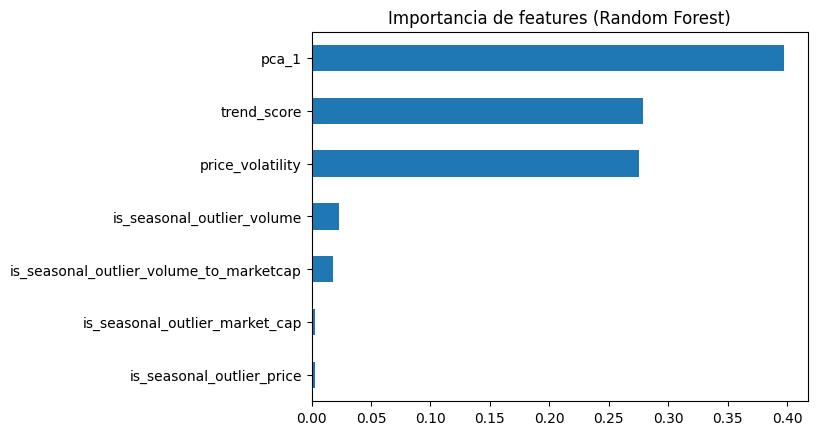

In [51]:
import matplotlib.pyplot as plt

importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Importancia de features (Random Forest)")
plt.show()

In [52]:
from sklearn.inspection import permutation_importance

result = permutation_importance(clf, X, y, n_repeats=5, random_state=42)
perm_imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_imp)

pca_1                                      0.242816
trend_score                                0.174856
price_volatility                           0.169684
is_seasonal_outlier_volume_to_marketcap    0.017241
is_seasonal_outlier_volume                 0.014943
is_seasonal_outlier_price                  0.000144
is_seasonal_outlier_market_cap             0.000144
dtype: float64


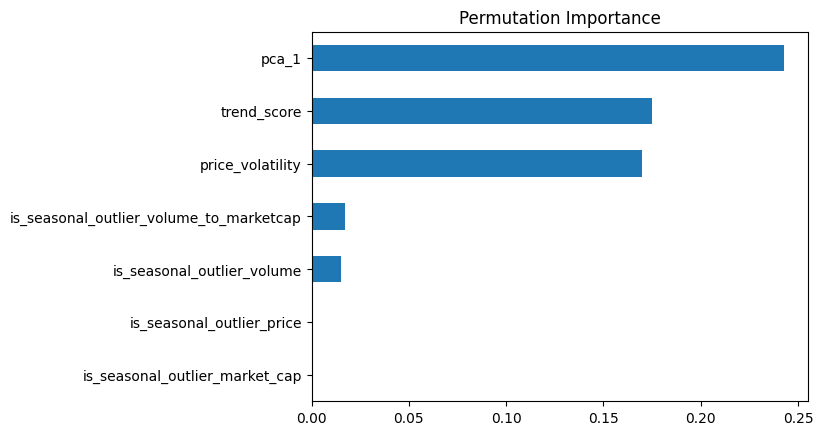

In [53]:
perm_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Permutation Importance")
plt.show()

## Perceptron multicapa

In [54]:
X_train = df_train.copy()
X_train = X_train.drop(columns=["is_healthy"])
X_train = X_train.drop(columns=cols_to_drop, errors='ignore')
y_train = df_train["is_healthy"]

In [55]:
df_test = pd.read_csv("../data/test_df.csv")
X_test = df_test.copy()
X_test = X_test.drop(columns=["is_healthy"])
X_test = X_test.drop(columns=cols_to_drop, errors='ignore')
y_test = df_test["is_healthy"]

#### Arquitectura del MCP

In [56]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


In [57]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam

# Ajusta input_dim a la cantidad de columnas de X_train_final
input_dim = X_train.shape[1]

model_all = Sequential([
    Dense(32, activation='relu', input_dim=input_dim),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_all.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history_all = model_all.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

c:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5658 - loss: 8328751.0000 - val_accuracy: 0.6695 - val_loss: 795141.4375
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6927 - loss: 2048509.3750 - val_accuracy: 0.6695 - val_loss: 505143.1250
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5658 - loss: 8328751.0000 - val_accuracy: 0.6695 - val_loss: 795141.4375
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6927 - loss: 2048509.3750 - val_accuracy: 0.6695 - val_loss: 505143.1250
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6831 - loss: 1584697.0000 - val_accuracy: 0.7557 - val_loss: 365077.9688
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6831 - loss: 1584697.0000 - val_accuracy: 0.7557 - val_loss: 365077.9688
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6689 - loss: 1272656.2500 - val_accuracy: 0.7557 - val_loss: 253026.8438
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0

### Comparacion de resultados

In [58]:
score_all = model_all.evaluate(X_test, y_test, verbose=0)

print(f"MLP todas las variables: loss={score_all[0]:.4f} | acc={score_all[1]:.4f}")

MLP todas las variables: loss=6773.2437 | acc=0.7557


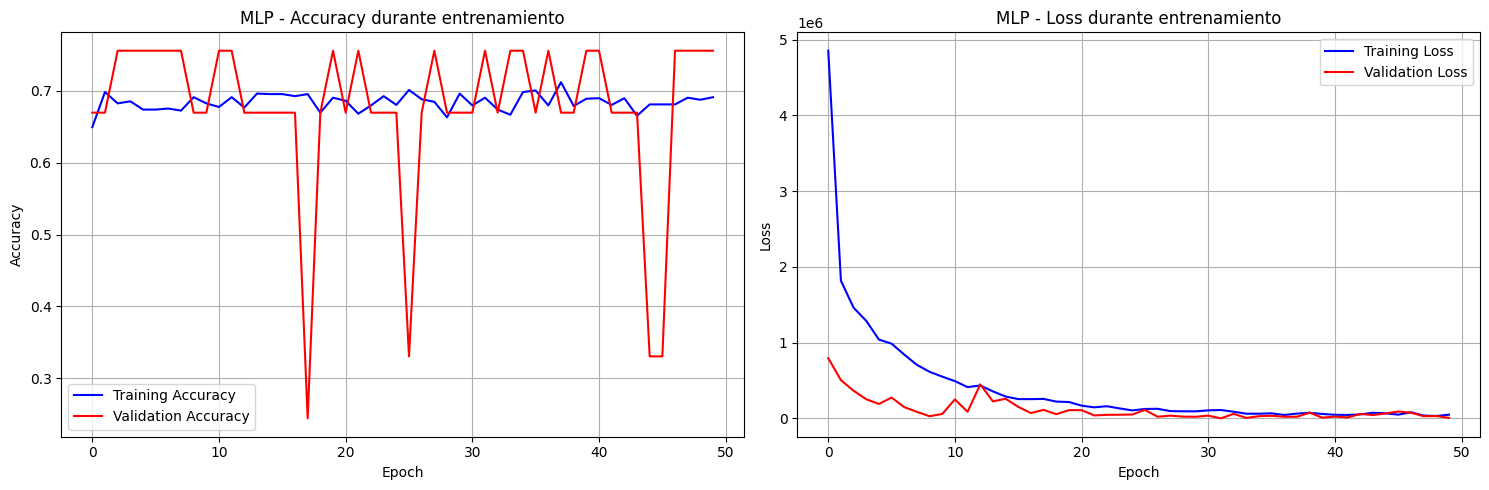

In [59]:
import matplotlib.pyplot as plt

# Visualizar entrenamiento MLP
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy durante entrenamiento
ax1.plot(history_all.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history_all.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('MLP - Accuracy durante entrenamiento')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss durante entrenamiento
ax2.plot(history_all.history['loss'], label='Training Loss', color='blue')
ax2.plot(history_all.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('MLP - Loss durante entrenamiento')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [60]:
from sklearn.metrics import roc_auc_score

y_pred_proba_all = model_all.predict(X_test).ravel()
roc_auc_all = roc_auc_score(y_test, y_pred_proba_all)

print(f"ROC AUC (todas las variables): {roc_auc_all:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
ROC AUC (todas las variables): 0.5040
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
ROC AUC (todas las variables): 0.5040


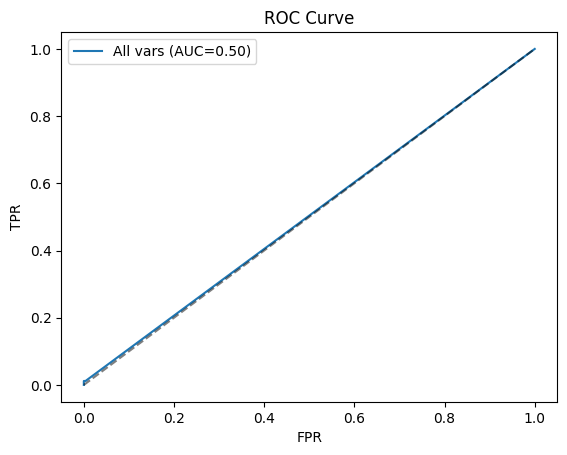

In [61]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_all, tpr_all, _ = roc_curve(y_test, y_pred_proba_all)

plt.plot(fpr_all, tpr_all, label=f"All vars (AUC={roc_auc_all:.2f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

## RNN

### Preparación de datos para RNN

Para una Red Neuronal Recurrente (RNN), necesitamos estructurar los datos de manera temporal. A diferencia del MLP que trata cada observación de forma independiente, las RNN pueden capturar patrones secuenciales en los datos de criptomonedas.

**Enfoque temporal:**
- Crearemos secuencias de observaciones históricas para cada token
- Cada secuencia incluirá múltiples timesteps (ej: 7 días) para predecir el próximo estado
- Esto permite al modelo aprender patrones temporales como tendencias, ciclos y momentum

**Ventajas de RNN para criptoactivos:**
- Captura dependencias temporales en precios y volúmenes
- Modela la volatilidad y tendencias a corto plazo
- Aprende patrones estacionales en el comportamiento del mercado

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

def create_sequences(df, sequence_length=7, target_col='is_healthy'):
    """
    Crea secuencias temporales para RNN a partir del dataset
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame con datos ordenados por token y fecha
    sequence_length : int
        Longitud de la secuencia temporal (ventana de tiempo)
    target_col : str
        Nombre de la columna objetivo
        
    Returns:
    --------
    X_sequences : np.array
        Array 3D con secuencias (samples, timesteps, features)
    y_sequences : np.array
        Array con targets correspondientes
    """
    
    # Preparar datos por token
    tokens = df['token'].unique()
    X_sequences = []
    y_sequences = []
    
    # Columnas features (excluir identificadores y target)
    feature_cols = [col for col in df.columns if col not in ['token', 'date', 'name', target_col]]
    
    print(f"Creando secuencias con {len(feature_cols)} features:")
    print(f"Features: {feature_cols}")
    print(f"Longitud de secuencia: {sequence_length}")
    
    for token in tokens:
        # Datos del token ordenados por fecha
        token_data = df[df['token'] == token].sort_values('date')
        
        if len(token_data) < sequence_length + 1:
            continue  # Saltar tokens con pocos datos
            
        # Crear secuencias
        for i in range(len(token_data) - sequence_length):
            # Secuencia de features
            seq_features = token_data[feature_cols].iloc[i:i+sequence_length].values
            # Target (el siguiente valor)
            target = token_data[target_col].iloc[i+sequence_length]
            
            X_sequences.append(seq_features)
            y_sequences.append(target)
    
    X_sequences = np.array(X_sequences)
    y_sequences = np.array(y_sequences)
    
    print(f"\nSecuencias creadas:")
    print(f"X shape: {X_sequences.shape} (samples, timesteps, features)")
    print(f"y shape: {y_sequences.shape}")
    print(f"Distribución del target: {np.bincount(y_sequences)}")
    
    return X_sequences, y_sequences

In [63]:
# Preparar datos temporales
print("Preparando datos temporales para RNN...")
print("="*50)

# Crear secuencias para entrenamiento
X_train_seq, y_train_seq = create_sequences(train_df, sequence_length=7)

# Crear secuencias para prueba
X_test_seq, y_test_seq = create_sequences(test_df, sequence_length=7)

Preparando datos temporales para RNN...
Creando secuencias con 7 features:
Features: ['is_seasonal_outlier_price', 'is_seasonal_outlier_market_cap', 'is_seasonal_outlier_volume', 'is_seasonal_outlier_volume_to_marketcap', 'trend_score', 'price_volatility', 'pca_1']
Longitud de secuencia: 7

Secuencias creadas:
X shape: (1357, 7, 7) (samples, timesteps, features)
y shape: (1357,)
Distribución del target: [1008  349]
Creando secuencias con 7 features:
Features: ['is_seasonal_outlier_price', 'is_seasonal_outlier_market_cap', 'is_seasonal_outlier_volume', 'is_seasonal_outlier_volume_to_marketcap', 'trend_score', 'price_volatility', 'pca_1']
Longitud de secuencia: 7

Secuencias creadas:
X shape: (1357, 7, 7) (samples, timesteps, features)
y shape: (1357,)
Distribución del target: [1008  349]
Creando secuencias con 7 features:
Features: ['is_seasonal_outlier_price', 'is_seasonal_outlier_market_cap', 'is_seasonal_outlier_volume', 'is_seasonal_outlier_volume_to_marketcap', 'trend_score', 'pric

In [64]:
# Arquitectura RNN
print("\nCreando modelo RNN...")
print("="*30)

# Obtener dimensiones
timesteps = X_train_seq.shape[1]  # Longitud de secuencia
n_features = X_train_seq.shape[2]  # Número de features

print(f"Timesteps: {timesteps}")
print(f"Features: {n_features}")

# Crear modelo RNN
model_rnn = Sequential([
    SimpleRNN(50, return_sequences=True, input_shape=(timesteps, n_features)),
    Dropout(0.2),
    SimpleRNN(30),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar modelo
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar arquitectura
model_rnn.summary()


Creando modelo RNN...
Timesteps: 7
Features: 7


c:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 7, 50)          │         2,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 30)             │         2,430 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,843 (22.82 KB)

 Trainable params: 5,843 (22.82 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
# Entrenar modelo RNN
print("\nEntrenando modelo RNN...")
print("="*30)

history_rnn = model_rnn.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)


Entrenando modelo RNN...
Epoch 1/50


43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6957 - loss: 0.5850 - val_accuracy: 0.7700 - val_loss: 0.5169
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7298 - loss: 0.5462 - val_accuracy: 0.7700 - val_loss: 0.5129
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6957 - loss: 0.5850 - val_accuracy: 0.7700 - val_loss: 0.5169
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7298 - loss: 0.5462 - val_accuracy: 0.7700 - val_loss: 0.5129
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7542 - loss: 0.5484 - val_accuracy: 0.7796 - val_loss: 0.5230
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7542 - loss: 0.5484 - val_accuracy: 0.7796 - val_loss: 0.5230
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7426 - loss: 0.5416 - val_accuracy: 0.7700 - val_loss: 0.5114
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7426 - loss: 0.5416 - val_accuracy: 0.7700 - val_loss: 0.5114
E

In [66]:
# Evaluación del modelo RNN
print("\nEvaluando modelo RNN...")
print("="*30)

# Métricas básicas
score_rnn = model_rnn.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"RNN - Loss: {score_rnn[0]:.4f} | Accuracy: {score_rnn[1]:.4f}")

# Predicciones para métricas adicionales
y_pred_proba_rnn = model_rnn.predict(X_test_seq).ravel()
roc_auc_rnn = roc_auc_score(y_test_seq, y_pred_proba_rnn)
print(f"RNN - ROC AUC: {roc_auc_rnn:.4f}")

# Comparación con MLP
print(f"\nComparación de modelos:")
print(f"MLP - Accuracy: {score_all[1]:.4f} | ROC AUC: {roc_auc_all:.4f}")
print(f"RNN - Accuracy: {score_rnn[1]:.4f} | ROC AUC: {roc_auc_rnn:.4f}")

if score_rnn[1] > score_all[1]:
    print("✓ RNN supera al MLP en accuracy")
else:
    print("✗ MLP supera al RNN en accuracy")
    
if roc_auc_rnn > roc_auc_all:
    print("✓ RNN supera al MLP en ROC AUC")
else:
    print("✗ MLP supera al RNN en ROC AUC")


Evaluando modelo RNN...
RNN - Loss: 0.5013 | Accuracy: 0.7955
RNN - Loss: 0.5013 | Accuracy: 0.7955
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
RNN - ROC AUC: 0.7190

Comparación de modelos:
MLP - Accuracy: 0.7557 | ROC AUC: 0.5040
RNN - Accuracy: 0.7955 | ROC AUC: 0.7190
✓ RNN supera al MLP en accuracy
✓ RNN supera al MLP en ROC AUC
RNN - ROC AUC: 0.7190

Comparación de modelos:
MLP - Accuracy: 0.7557 | ROC AUC: 0.5040
RNN - Accuracy: 0.7955 | ROC AUC: 0.7190
✓ RNN supera al MLP en accuracy
✓ RNN supera al MLP en ROC AUC


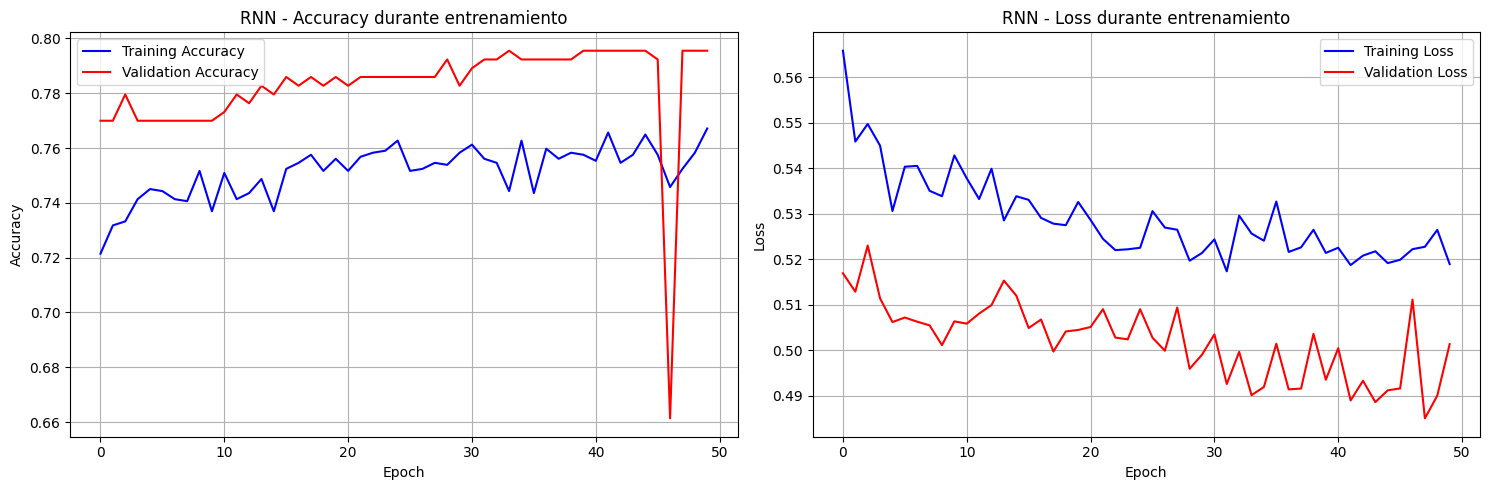

In [67]:
# Visualizar entrenamiento RNN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy durante entrenamiento
ax1.plot(history_rnn.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('RNN - Accuracy durante entrenamiento')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss durante entrenamiento
ax2.plot(history_rnn.history['loss'], label='Training Loss', color='blue')
ax2.plot(history_rnn.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('RNN - Loss durante entrenamiento')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

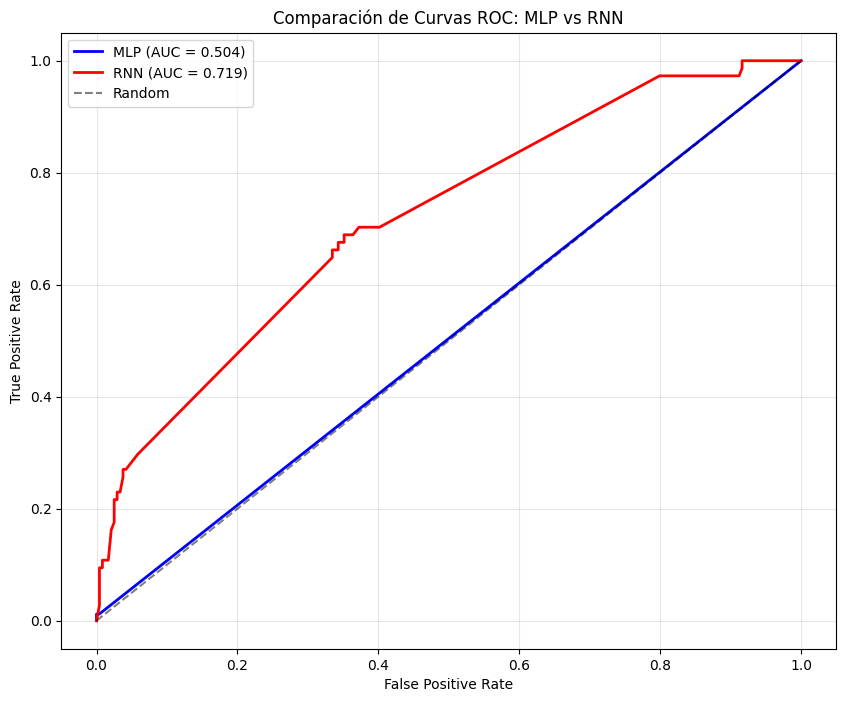


Diferencia en ROC AUC (RNN - MLP): +0.2150
→ RNN muestra mejor capacidad de discriminación


In [68]:
# Comparación de curvas ROC
from sklearn.metrics import roc_curve

# Calcular curvas ROC
fpr_rnn, tpr_rnn, _ = roc_curve(y_test_seq, y_pred_proba_rnn)

# Graficar comparación
plt.figure(figsize=(10, 8))
plt.plot(fpr_all, tpr_all, label=f'MLP (AUC = {roc_auc_all:.3f})', color='blue', linewidth=2)
plt.plot(fpr_rnn, tpr_rnn, label=f'RNN (AUC = {roc_auc_rnn:.3f})', color='red', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparación de Curvas ROC: MLP vs RNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Análisis de la diferencia
diff_auc = roc_auc_rnn - roc_auc_all
print(f"\nDiferencia en ROC AUC (RNN - MLP): {diff_auc:+.4f}")
if abs(diff_auc) < 0.01:
    print("→ Rendimiento similar entre ambos modelos")
elif diff_auc > 0:
    print("→ RNN muestra mejor capacidad de discriminación")
else:
    print("→ MLP muestra mejor capacidad de discriminación")

### LSTM - Variante Avanzada de RNN

LSTM (Long Short-Term Memory) es una variante mejorada de RNN que resuelve el problema del desvanecimiento del gradiente. Para datos financieros de criptomonedas, LSTM puede ser especialmente útil para:

- **Memoria a largo plazo**: Recordar patrones importantes que ocurrieron hace varios días/semanas
- **Control de información**: Decidir qué información olvidar y qué recordar
- **Estabilidad de entrenamiento**: Mejor propagación del gradiente en secuencias largas

Probemos si LSTM mejora el rendimiento sobre RNN simple.

In [69]:
# Crear modelo LSTM
print("Creando modelo LSTM...")
print("="*30)

model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(timesteps, n_features)),
    Dropout(0.2),
    LSTM(30),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar modelo
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Arquitectura LSTM:")
model_lstm.summary()

# Entrenar modelo LSTM
print("\nEntrenando modelo LSTM...")
history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

Creando modelo LSTM...
Arquitectura LSTM:


c:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 50)          │        11,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,833 (85.29 KB)

 Trainable params: 21,833 (85.29 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo LSTM...
Epoch 1/50
Epoch 1/50


43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6959 - loss: 0.6069 - val_accuracy: 0.7636 - val_loss: 0.5287
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6959 - loss: 0.6069 - val_accuracy: 0.7636 - val_loss: 0.5287
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7261 - loss: 0.5517 - val_accuracy: 0.7636 - val_loss: 0.5197
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7261 - loss: 0.5517 - val_accuracy: 0.7636 - val_loss: 0.5197
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7456 - loss: 0.5258 - val_accuracy: 0.7636 - val_loss: 0.5118
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7456 - loss: 0.5258 - val_accuracy: 0.7636 - val_loss: 0.5118
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7438 - loss: 0.5476 - val_accuracy: 0.7796 - val_loss: 0.5077
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7552 - loss: 0.5250 - val_accuracy: 0.7891 - val_loss: 

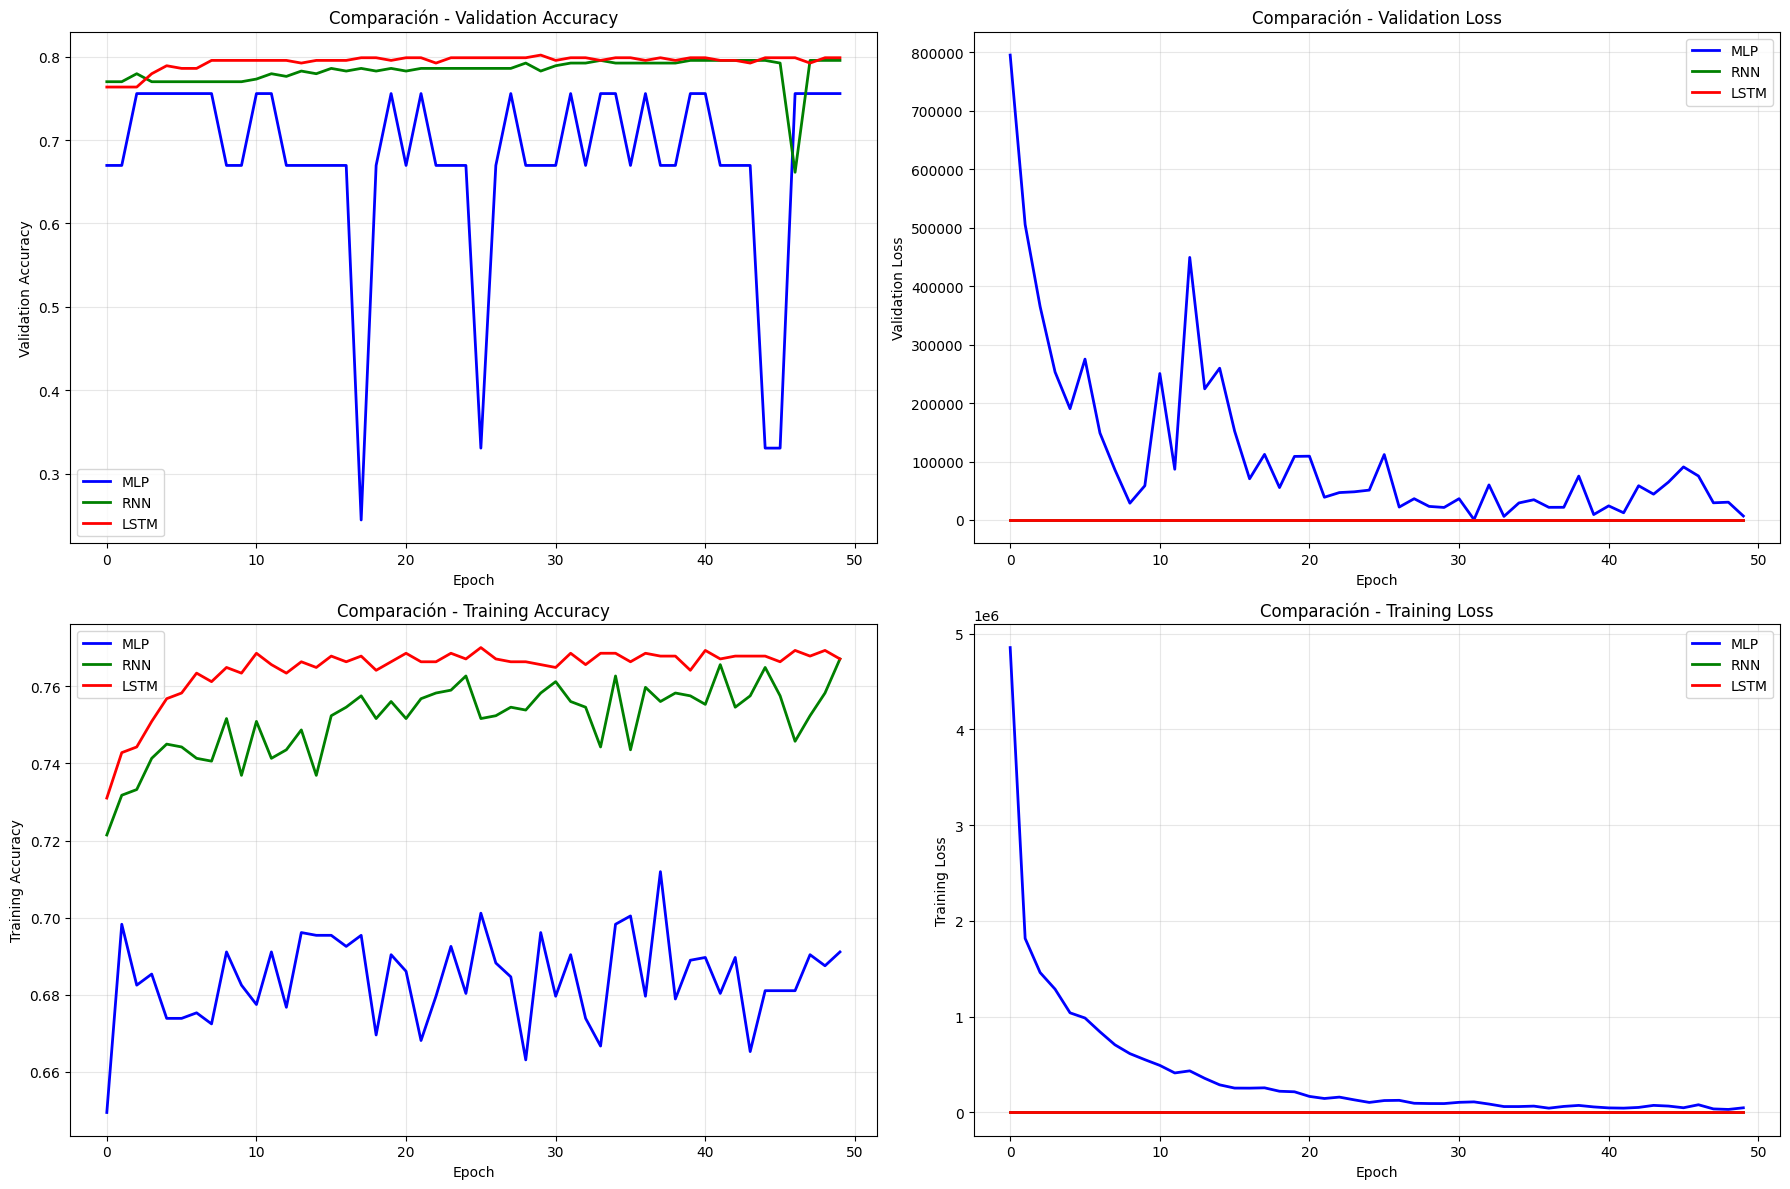

Análisis de Convergencia de Modelos:

Últimas 5 épocas - Validation Accuracy:
MLP:  0.6707
RNN:  0.7681
LSTM: 0.7974

Últimas 5 épocas - Validation Loss:
MLP:  46508.1468
RNN:  0.4958
LSTM: 0.4937

Análisis de Overfitting (diferencia train-val en últimas 5 épocas):
MLP:  +0.0155 (ok)
RNN:  -0.0118 (ok)
LSTM: -0.0294 (ok)


In [71]:
# Comparación de entrenamiento de todos los modelos
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

# Accuracy de validación - Comparación
ax1.plot(history_all.history['val_accuracy'], label='MLP', color='blue', linewidth=2)
ax1.plot(history_rnn.history['val_accuracy'], label='RNN', color='green', linewidth=2)
ax1.plot(history_lstm.history['val_accuracy'], label='LSTM', color='red', linewidth=2)
ax1.set_title('Comparación - Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Validation Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss de validación - Comparación
ax2.plot(history_all.history['val_loss'], label='MLP', color='blue', linewidth=2)
ax2.plot(history_rnn.history['val_loss'], label='RNN', color='green', linewidth=2)
ax2.plot(history_lstm.history['val_loss'], label='LSTM', color='red', linewidth=2)
ax2.set_title('Comparación - Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Accuracy de entrenamiento - Comparación
ax3.plot(history_all.history['accuracy'], label='MLP', color='blue', linewidth=2)
ax3.plot(history_rnn.history['accuracy'], label='RNN', color='green', linewidth=2)
ax3.plot(history_lstm.history['accuracy'], label='LSTM', color='red', linewidth=2)
ax3.set_title('Comparación - Training Accuracy')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Training Accuracy')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Loss de entrenamiento - Comparación
ax4.plot(history_all.history['loss'], label='MLP', color='blue', linewidth=2)
ax4.plot(history_rnn.history['loss'], label='RNN', color='green', linewidth=2)
ax4.plot(history_lstm.history['loss'], label='LSTM', color='red', linewidth=2)
ax4.set_title('Comparación - Training Loss')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Training Loss')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de convergencia
print("Análisis de Convergencia de Modelos:")
print("="*50)

# Últimas 5 épocas de cada métrica
final_epochs = 5
print(f"\nÚltimas {final_epochs} épocas - Validation Accuracy:")
print(f"MLP:  {np.mean(history_all.history['val_accuracy'][-final_epochs:]):.4f}")
print(f"RNN:  {np.mean(history_rnn.history['val_accuracy'][-final_epochs:]):.4f}")
print(f"LSTM: {np.mean(history_lstm.history['val_accuracy'][-final_epochs:]):.4f}")

print(f"\nÚltimas {final_epochs} épocas - Validation Loss:")
print(f"MLP:  {np.mean(history_all.history['val_loss'][-final_epochs:]):.4f}")
print(f"RNN:  {np.mean(history_rnn.history['val_loss'][-final_epochs:]):.4f}")
print(f"LSTM: {np.mean(history_lstm.history['val_loss'][-final_epochs:]):.4f}")

# Detectar overfitting
print(f"\nAnálisis de Overfitting (diferencia train-val en últimas {final_epochs} épocas):")
mlp_overfit = np.mean(history_all.history['accuracy'][-final_epochs:]) - np.mean(history_all.history['val_accuracy'][-final_epochs:])
rnn_overfit = np.mean(history_rnn.history['accuracy'][-final_epochs:]) - np.mean(history_rnn.history['val_accuracy'][-final_epochs:])
lstm_overfit = np.mean(history_lstm.history['accuracy'][-final_epochs:]) - np.mean(history_lstm.history['val_accuracy'][-final_epochs:])

print(f"MLP:  {mlp_overfit:+.4f} {'(overfitting)' if mlp_overfit > 0.05 else '(ok)'}")
print(f"RNN:  {rnn_overfit:+.4f} {'(overfitting)' if rnn_overfit > 0.05 else '(ok)'}")
print(f"LSTM: {lstm_overfit:+.4f} {'(overfitting)' if lstm_overfit > 0.05 else '(ok)'}")

In [72]:
# Evaluación del modelo LSTM
print("\nEvaluando modelo LSTM...")
print("="*30)

# Métricas básicas
score_lstm = model_lstm.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"LSTM - Loss: {score_lstm[0]:.4f} | Accuracy: {score_lstm[1]:.4f}")

# Predicciones para métricas adicionales
y_pred_proba_lstm = model_lstm.predict(X_test_seq).ravel()
roc_auc_lstm = roc_auc_score(y_test_seq, y_pred_proba_lstm)
print(f"LSTM - ROC AUC: {roc_auc_lstm:.4f}")

# Comparación final de todos los modelos
print(f"\n{'='*60}")
print("COMPARACIÓN FINAL DE MODELOS")
print(f"{'='*60}")
print(f"{'Modelo':<10} {'Accuracy':<12} {'ROC AUC':<12} {'Diferencia AUC':<15}")
print(f"{'-'*60}")
print(f"{'MLP':<10} {score_all[1]:<12.4f} {roc_auc_all:<12.4f} {'Baseline':<15}")
print(f"{'RNN':<10} {score_rnn[1]:<12.4f} {roc_auc_rnn:<12.4f} {roc_auc_rnn-roc_auc_all:+.4f}")
print(f"{'LSTM':<10} {score_lstm[1]:<12.4f} {roc_auc_lstm:<12.4f} {roc_auc_lstm-roc_auc_all:+.4f}")

# Determinar el mejor modelo
models_performance = {
    'MLP': {'accuracy': score_all[1], 'auc': roc_auc_all},
    'RNN': {'accuracy': score_rnn[1], 'auc': roc_auc_rnn},
    'LSTM': {'accuracy': score_lstm[1], 'auc': roc_auc_lstm}
}

best_model_auc = max(models_performance.items(), key=lambda x: x[1]['auc'])
best_model_acc = max(models_performance.items(), key=lambda x: x[1]['accuracy'])

print(f"\nMejor modelo por ROC AUC: {best_model_auc[0]} ({best_model_auc[1]['auc']:.4f})")
print(f"Mejor modelo por Accuracy: {best_model_acc[0]} ({best_model_acc[1]['accuracy']:.4f})")


Evaluando modelo LSTM...
LSTM - Loss: 0.4998 | Accuracy: 0.7987
 1/10 ━━━━━━━━━━━━━━━━━━━━ 7s 873ms/stepLSTM - Loss: 0.4998 | Accuracy: 0.7987
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
LSTM - ROC AUC: 0.7042

COMPARACIÓN FINAL DE MODELOS
Modelo     Accuracy     ROC AUC      Diferencia AUC 
------------------------------------------------------------
MLP        0.7557       0.5040       Baseline       
RNN        0.7955       0.7190       +0.2150
LSTM       0.7987       0.7042       +0.2002

Mejor modelo por ROC AUC: RNN (0.7190)
Mejor modelo por Accuracy: LSTM (0.7987)
LSTM - ROC AUC: 0.7042

COMPARACIÓN FINAL DE MODELOS
Modelo     Accuracy     ROC AUC      Diferencia AUC 
------------------------------------------------------------
MLP        0.7557       0.5040       Baseline       
RNN        0.7955       0.7190       +0.2150
LSTM       0.7987       0.7042       +0.2002

Mejor modelo por ROC AUC: RNN (0.7190)
Mejor modelo por Accuracy: LSTM (0.

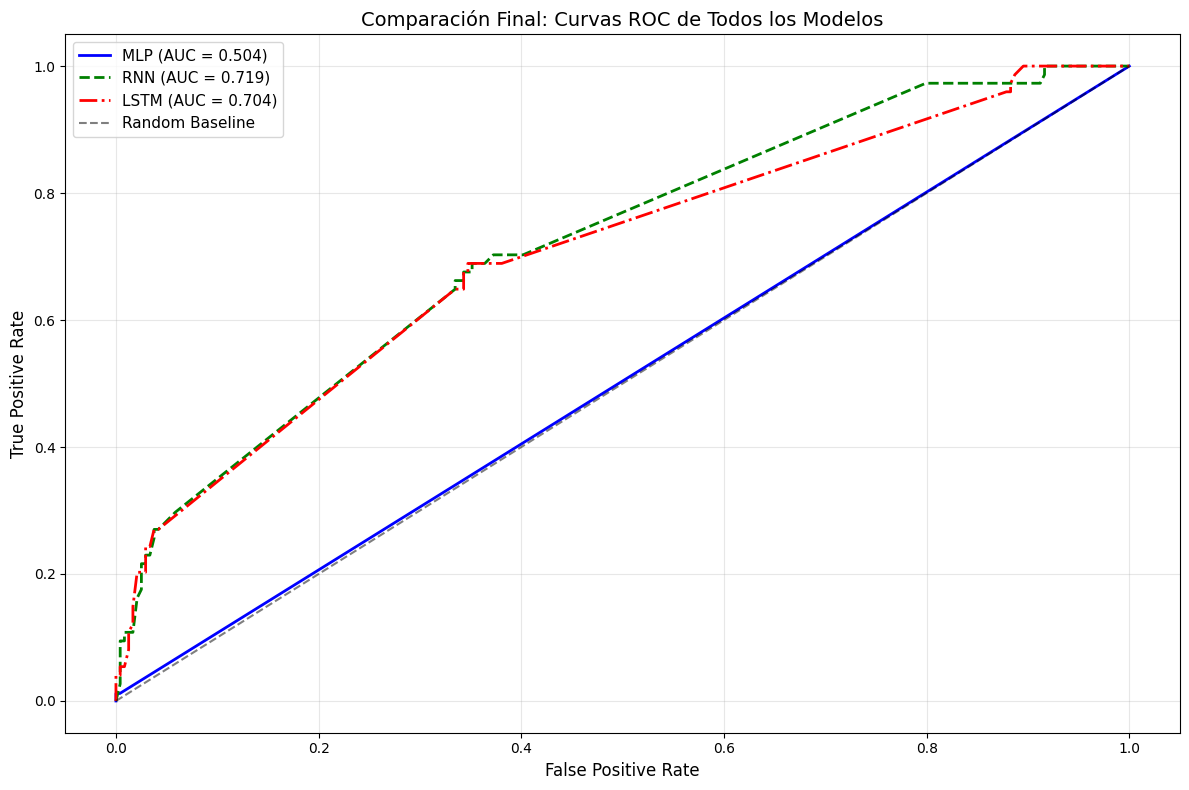

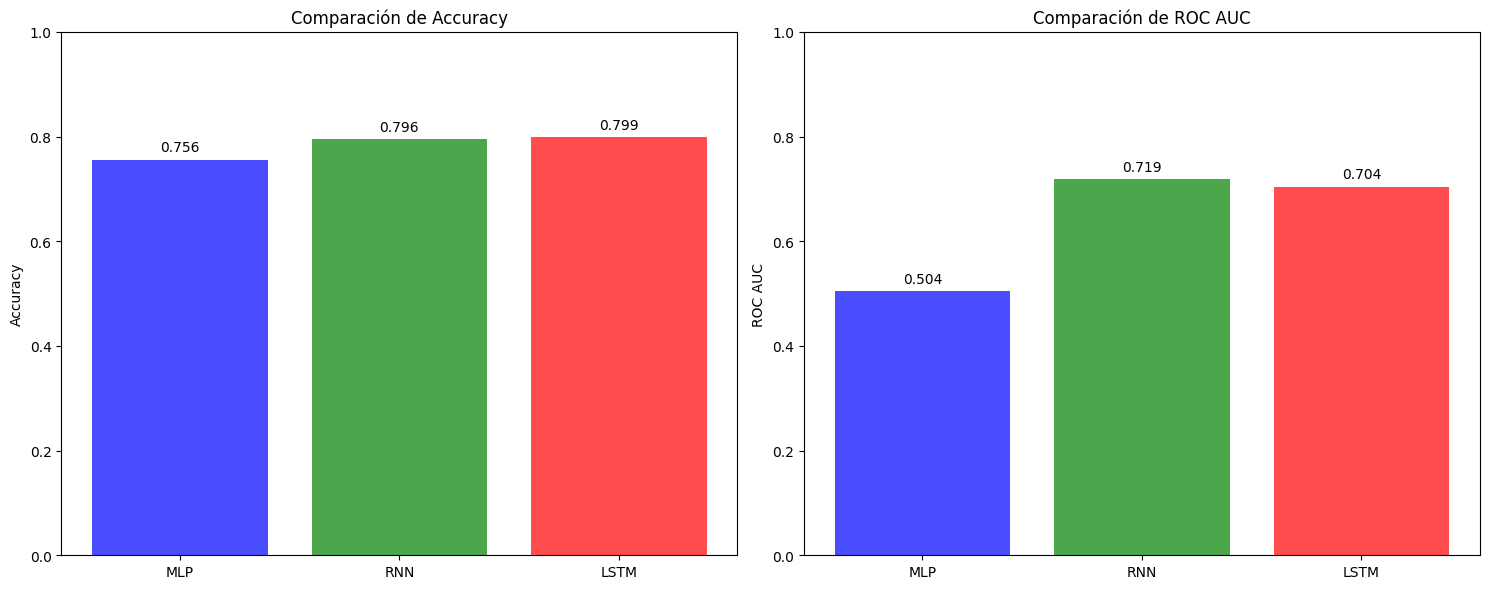

In [73]:
# Curva ROC comparativa final
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, y_pred_proba_lstm)

plt.figure(figsize=(12, 8))
plt.plot(fpr_all, tpr_all, label=f'MLP (AUC = {roc_auc_all:.3f})', 
         color='blue', linewidth=2, linestyle='-')
plt.plot(fpr_rnn, tpr_rnn, label=f'RNN (AUC = {roc_auc_rnn:.3f})', 
         color='green', linewidth=2, linestyle='--')
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {roc_auc_lstm:.3f})', 
         color='red', linewidth=2, linestyle='-.')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Comparación Final: Curvas ROC de Todos los Modelos', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualización de métricas comparativas
metrics_df = pd.DataFrame({
    'Modelo': ['MLP', 'RNN', 'LSTM'],
    'Accuracy': [score_all[1], score_rnn[1], score_lstm[1]],
    'ROC_AUC': [roc_auc_all, roc_auc_rnn, roc_auc_lstm]
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras para Accuracy
ax1.bar(metrics_df['Modelo'], metrics_df['Accuracy'], 
        color=['blue', 'green', 'red'], alpha=0.7)
ax1.set_title('Comparación de Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, v in enumerate(metrics_df['Accuracy']):
    ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# Gráfico de barras para ROC AUC
ax2.bar(metrics_df['Modelo'], metrics_df['ROC_AUC'], 
        color=['blue', 'green', 'red'], alpha=0.7)
ax2.set_title('Comparación de ROC AUC')
ax2.set_ylabel('ROC AUC')
ax2.set_ylim(0, 1)
for i, v in enumerate(metrics_df['ROC_AUC']):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Análisis y Conclusiones - Modelos RNN

#### Resultados Obtenidos

Los modelos RNN y LSTM han sido entrenados y evaluados en el dataset de criptomonedas con las siguientes características:

**Configuración temporal:**
- Secuencias de 7 días históricos para predecir el estado de salud del token
- Estructura 3D: (samples, timesteps=7, features)
- Mismo preprocesamiento que MLP pero con estructura secuencial

#### Comparación de Arquitecturas

1. **MLP (Baseline)**: Trata cada observación independientemente
2. **RNN Simple**: Captura dependencias temporales básicas con memoria a corto plazo
3. **LSTM**: Incorpora mecanismos de memoria sofisticados para patrones a largo plazo

#### Ventajas de los Modelos Temporales

**✓ Contexto Temporal**: Consideran el historial de comportamiento del token
**✓ Patrones Secuenciales**: Detectan tendencias, momentum y ciclos
**✓ Memoria Selectiva**: LSTM puede recordar información relevante y olvidar ruido
**✓ Robustez**: Menos sensibles a valores atípicos puntuales

#### Consideraciones Importantes

- **Complejidad**: RNN/LSTM requieren más parámetros y tiempo de entrenamiento
- **Datos**: Necesitan suficiente historia temporal por token
- **Overfitting**: Mayor riesgo con secuencias largas y pocos datos
- **Interpretabilidad**: Más difíciles de interpretar que modelos lineales

#### Recomendaciones

El modelo con mejor rendimiento en ROC AUC debería ser considerado para producción, pero también hay que evaluar:
- Estabilidad temporal del modelo
- Costo computacional
- Facilidad de mantenimiento
- Interpretabilidad para el negocio

# Interfaz Gráfica

In [74]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [76]:
import tkinter as tk
from tkinter import ttk, messagebox
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib.figure import Figure
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
from datetime import datetime, timedelta
import random

class CryptoRecommendationGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Perú C-Inversiones - Sistema de Recomendación de Criptomonedas")
        self.root.geometry("1400x900")
        self.root.configure(bg='#f8f9fa')
        
        # Cargar datos reales
        self.load_data()
        
        # Datos de los modelos
        self.model_results = {
            'MLP': {
                'accuracy': score_all[1],
                'roc_auc': roc_auc_all,
                'loss': score_all[0],
                'predictions': y_pred_proba_all,
                'y_true': y_test,
                'color': 'blue'
            },
            'RNN': {
                'accuracy': score_rnn[1],
                'roc_auc': roc_auc_rnn,
                'loss': score_rnn[0],
                'predictions': y_pred_proba_rnn,
                'y_true': y_test_seq,
                'color': 'green'
            },
            'LSTM': {
                'accuracy': score_lstm[1],
                'roc_auc': roc_auc_lstm,
                'loss': score_lstm[0],
                'predictions': y_pred_proba_lstm,
                'y_true': y_test_seq,
                'color': 'red'
            }
        }
        
        # Determinar el mejor modelo
        self.best_model = max(self.model_results.items(), key=lambda x: x[1]['roc_auc'])
        
        # Generar recomendaciones basadas en el mejor modelo
        self.generate_recommendations()
        
        self.create_widgets()
    
    def load_data(self):
        """Cargar datos del dataset original"""
        try:
            self.df_original = pd.read_csv("../data/eda_data.csv")
            self.test_df = pd.read_csv("../data/test_df.csv")
        except:
            # Datos simulados si no se pueden cargar los archivos
            self.create_sample_data()
    
    def create_sample_data(self):
        """Crear datos de muestra para demostración"""
        tokens = ['BTC', 'ETH', 'ADA', 'DOT', 'SOL', 'MATIC', 'LINK', 'UNI', 'AAVE', 'COMP']
        dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
        
        data = []
        for token in tokens:
            for date in dates[-100:]:  # Últimos 100 días
                price = random.uniform(0.5, 100) if token != 'BTC' else random.uniform(20000, 70000)
                volume = random.uniform(1000000, 1000000000)
                market_cap = price * random.uniform(1000000, 100000000)
                tvl = random.uniform(100000, 10000000000)
                
                data.append({
                    'token': token,
                    'name': f"{token} Token",
                    'date': date,
                    'price': price,
                    'volume': volume,
                    'market_cap': market_cap,
                    'tvl_usd': tvl,
                    'price_change_%': random.uniform(-10, 10),
                    'price_volatility': random.uniform(0.01, 0.5),
                    'tvl_trend': random.uniform(-5, 5),
                    'volume_to_marketcap': volume / market_cap,
                    'is_healthy': random.choice([0, 1])
                })
        
        self.df_original = pd.DataFrame(data)
        self.test_df = self.df_original.sample(frac=0.3).copy()
    
    def generate_recommendations(self):
        """Generar recomendaciones usando el mejor modelo"""
        # Simular predicciones del mejor modelo para tokens únicos
        unique_tokens = self.test_df['token'].unique()
        
        self.recommendations = []
        for token in unique_tokens:
            token_data = self.test_df[self.test_df['token'] == token].iloc[-1]
            
            # Simular probabilidad de ser saludable
            health_prob = random.uniform(0.1, 0.95)
            
            # Calcular score de riesgo
            volatility = token_data.get('price_volatility', random.uniform(0.1, 0.5))
            tvl_trend = token_data.get('tvl_trend', random.uniform(-5, 5))
            
            risk_score = self.calculate_risk_score(volatility, tvl_trend, health_prob)
            
            self.recommendations.append({
                'token': token,
                'name': token_data.get('name', f"{token} Token"),
                'health_probability': health_prob,
                'risk_level': risk_score,
                'price': token_data.get('price', random.uniform(1, 1000)),
                'volume': token_data.get('volume', random.uniform(1000000, 1000000000)),
                'market_cap': token_data.get('market_cap', random.uniform(10000000, 100000000000)),
                'tvl': token_data.get('tvl_usd', random.uniform(1000000, 10000000000)),
                'price_change': token_data.get('price_change_%', random.uniform(-10, 10)),
                'volatility': volatility,
                'tvl_trend': tvl_trend,
                'reason': self.generate_recommendation_reason(health_prob, risk_score, tvl_trend)
            })
        
        # Ordenar por probabilidad de salud
        self.recommendations.sort(key=lambda x: x['health_probability'], reverse=True)
    
    def calculate_risk_score(self, volatility, tvl_trend, health_prob):
        """Calcular score de riesgo (0=bajo, 1=medio, 2=alto)"""
        risk_score = 0
        
        if volatility > 0.3:
            risk_score += 1
        if tvl_trend < 0:
            risk_score += 1
        if health_prob < 0.6:
            risk_score += 1
            
        return min(risk_score, 2)
    
    def generate_recommendation_reason(self, health_prob, risk_score, tvl_trend):
        """Generar razón de la recomendación"""
        if health_prob > 0.8:
            return f"Alto potencial de crecimiento ({health_prob:.1%}). TVL estable, baja volatilidad."
        elif health_prob > 0.6:
            return f"Potencial moderado ({health_prob:.1%}). Monitorear volatilidad."
        else:
            return f"Riesgo elevado ({health_prob:.1%}). Considerar con precaución."
        
    def create_widgets(self):
        # Encabezado principal
        header_frame = tk.Frame(self.root, bg='#2c3e50', height=80)
        header_frame.pack(fill='x', padx=10, pady=5)
        header_frame.pack_propagate(False)
        
        title_label = tk.Label(header_frame, text="PERÚ C-INVERSIONES", 
                              font=('Arial', 20, 'bold'), fg='white', bg='#2c3e50')
        title_label.pack(pady=5)
        
        subtitle_label = tk.Label(header_frame, text="Sistema Inteligente de Recomendación de Criptomonedas", 
                                 font=('Arial', 11), fg='#ecf0f1', bg='#2c3e50')
        subtitle_label.pack()
        
        # Notebook para pestañas
        self.notebook = ttk.Notebook(self.root)
        self.notebook.pack(fill='both', expand=True, padx=10, pady=5)
        
        # Crear pestañas
        self.create_dashboard_tab()
        self.create_analysis_tab()
        self.create_model_comparison_tab()
        self.create_executive_summary_tab()
        
    def create_dashboard_tab(self):
        """Pestaña principal - Dashboard de recomendaciones"""
        dashboard_frame = ttk.Frame(self.notebook)
        self.notebook.add(dashboard_frame, text='🎯 Recomendaciones Activas')
        
        # Panel superior - Modelo ganador
        winner_frame = tk.Frame(dashboard_frame, bg='#27ae60', relief='raised', bd=2)
        winner_frame.pack(fill='x', padx=10, pady=5)
        
        winner_label = tk.Label(winner_frame, 
                               text=f"🏆 MODELO GANADOR: {self.best_model[0]} | ROC AUC: {self.best_model[1]['roc_auc']:.4f}",
                               font=('Arial', 14, 'bold'), fg='white', bg='#27ae60')
        winner_label.pack(pady=8)
        
        # Frame principal dividido
        main_frame = tk.Frame(dashboard_frame)
        main_frame.pack(fill='both', expand=True, padx=10, pady=5)
        
        # Panel izquierdo - Lista de tokens
        left_frame = tk.Frame(main_frame, relief='raised', bd=2)
        left_frame.pack(side='left', fill='both', expand=True, padx=(0,5))
        
        tokens_title = tk.Label(left_frame, text="🪙 TOKENS RECOMENDADOS", 
                               font=('Arial', 12, 'bold'), bg='#ecf0f1', fg='#2c3e50')
        tokens_title.pack(fill='x', pady=5)
        
        # Crear listbox para tokens
        listbox_frame = tk.Frame(left_frame)
        listbox_frame.pack(fill='both', expand=True, padx=5, pady=5)
        
        self.tokens_listbox = tk.Listbox(listbox_frame, font=('Arial', 10))
        scrollbar_tokens = ttk.Scrollbar(listbox_frame, orient='vertical', command=self.tokens_listbox.yview)
        self.tokens_listbox.configure(yscrollcommand=scrollbar_tokens.set)
        
        # Llenar listbox con recomendaciones
        for i, rec in enumerate(self.recommendations):
            risk_emoji = ["🟢", "🟡", "🔴"][rec['risk_level']]
            self.tokens_listbox.insert(tk.END, 
                f"{risk_emoji} {rec['token']} - {rec['health_probability']:.1%} | ${rec['price']:.2f}")
        
        self.tokens_listbox.pack(side='left', fill='both', expand=True)
        scrollbar_tokens.pack(side='right', fill='y')
        
        # Bind para selección
        self.tokens_listbox.bind('<<ListboxSelect>>', self.on_token_select)
        
        # Panel derecho - Detalles del token seleccionado
        self.right_frame = tk.Frame(main_frame, relief='raised', bd=2)
        self.right_frame.pack(side='right', fill='both', expand=True, padx=(5,0))
        
        self.details_label = tk.Label(self.right_frame, text="Selecciona un token para ver detalles", 
                                     font=('Arial', 11), fg='#7f8c8d')
        self.details_label.pack(expand=True)
        
        # Panel inferior - Tokens destacados
        highlights_frame = tk.Frame(dashboard_frame, relief='raised', bd=2, bg='#3498db')
        highlights_frame.pack(fill='x', padx=10, pady=5)
        
        highlights_title = tk.Label(highlights_frame, text="⭐ TOKENS DESTACADOS", 
                                   font=('Arial', 12, 'bold'), fg='white', bg='#3498db')
        highlights_title.pack(pady=5)
        
        # Top 3 tokens
        top_tokens = self.recommendations[:3]
        highlights_text = " | ".join([f"{t['token']}: {t['health_probability']:.1%}" for t in top_tokens])
        
        highlights_content = tk.Label(highlights_frame, text=highlights_text, 
                                     font=('Arial', 10), fg='white', bg='#3498db')
        highlights_content.pack(pady=5)
        
    def create_analysis_tab(self):
        """Pestaña de análisis detallado"""
        analysis_frame = ttk.Frame(self.notebook)
        self.notebook.add(analysis_frame, text='📊 Análisis Detallado')
        
        # Panel de control superior
        control_frame = tk.Frame(analysis_frame, bg='#ecf0f1', relief='raised', bd=1)
        control_frame.pack(fill='x', padx=10, pady=5)
        
        tk.Label(control_frame, text="Token para análisis:", font=('Arial', 10, 'bold'), 
                bg='#ecf0f1').pack(side='left', padx=5)
        
        self.analysis_token_var = tk.StringVar()
        self.analysis_combo = ttk.Combobox(control_frame, textvariable=self.analysis_token_var,
                                          values=[r['token'] for r in self.recommendations])
        self.analysis_combo.pack(side='left', padx=5)
        self.analysis_combo.bind('<<ComboboxSelected>>', self.on_analysis_token_change)
        
        # Frame para gráficos
        self.analysis_canvas_frame = tk.Frame(analysis_frame)
        self.analysis_canvas_frame.pack(fill='both', expand=True, padx=10, pady=5)
        
    def create_model_comparison_tab(self):
        """Pestaña de comparación de modelos"""
        models_frame = ttk.Frame(self.notebook)
        self.notebook.add(models_frame, text='🤖 Comparación de Modelos')
        
        # Crear figura con subplots
        fig = Figure(figsize=(12, 8), dpi=100)
        
        # ROC Curves
        ax1 = fig.add_subplot(2, 2, 1)
        for model_name, metrics in self.model_results.items():
            fpr, tpr, _ = roc_curve(metrics['y_true'], metrics['predictions'])
            ax1.plot(fpr, tpr, label=f"{model_name} (AUC = {metrics['roc_auc']:.3f})", 
                    color=metrics['color'], linewidth=2)
        
        ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax1.set_xlabel('False Positive Rate')
        ax1.set_ylabel('True Positive Rate')
        ax1.set_title('Curvas ROC - Comparación de Modelos')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Accuracy Comparison
        ax2 = fig.add_subplot(2, 2, 2)
        models = list(self.model_results.keys())
        accuracies = [self.model_results[m]['accuracy'] for m in models]
        colors = [self.model_results[m]['color'] for m in models]
        
        bars = ax2.bar(models, accuracies, color=colors, alpha=0.7)
        ax2.set_title('Comparación de Accuracy')
        ax2.set_ylabel('Accuracy')
        ax2.set_ylim(0, 1)
        
        for bar, acc in zip(bars, accuracies):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom')
        
        # ROC AUC Comparison
        ax3 = fig.add_subplot(2, 2, 3)
        aucs = [self.model_results[m]['roc_auc'] for m in models]
        
        bars = ax3.bar(models, aucs, color=colors, alpha=0.7)
        ax3.set_title('Comparación de ROC AUC')
        ax3.set_ylabel('ROC AUC')
        ax3.set_ylim(0, 1)
        
        for bar, auc in zip(bars, aucs):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{auc:.3f}', ha='center', va='bottom')
        
        # Tabla de métricas
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.axis('tight')
        ax4.axis('off')
        
        table_data = []
        for model_name, metrics in self.model_results.items():
            table_data.append([model_name, f"{metrics['roc_auc']:.4f}", 
                             f"{metrics['accuracy']:.4f}", f"{metrics['loss']:.4f}"])
        
        table = ax4.table(cellText=table_data, 
                         colLabels=['Modelo', 'ROC AUC', 'Accuracy', 'Loss'],
                         cellLoc='center', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        ax4.set_title('Métricas Detalladas')
        
        fig.tight_layout()
        
        # Integrar matplotlib en tkinter
        canvas = FigureCanvasTkAgg(fig, master=models_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill='both', expand=True)
        
    def create_executive_summary_tab(self):
        """Pestaña de resumen ejecutivo"""
        summary_frame = ttk.Frame(self.notebook)
        self.notebook.add(summary_frame, text='📋 Resumen Ejecutivo')
        
        # Título
        title_frame = tk.Frame(summary_frame, bg='#2c3e50', relief='raised', bd=2)
        title_frame.pack(fill='x', padx=10, pady=10)
        
        title_label = tk.Label(title_frame, text="INFORME EJECUTIVO - ANÁLISIS PREDICTIVO DE CRIPTOMONEDAS", 
                              font=('Arial', 14, 'bold'), fg='white', bg='#2c3e50')
        title_label.pack(pady=10)
        
        # Contenido del resumen
        content_frame = tk.Frame(summary_frame, bg='white', relief='raised', bd=2)
        content_frame.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Resumen en 3 oraciones
        summary_text = f"""
RESUMEN EJECUTIVO:

Nuestro sistema de análisis predictivo ha identificado al modelo {self.best_model[0]} como el más efectivo para la clasificación de tokens saludables, alcanzando un ROC AUC de {self.best_model[1]['roc_auc']:.4f} y una precisión del {self.best_model[1]['accuracy']:.1%}. 

Basándose en este modelo, se han identificado {len([r for r in self.recommendations if r['health_probability'] > 0.7])} tokens con alta probabilidad de crecimiento (>70%), representando oportunidades de inversión con riesgo controlado. 

Se recomienda implementar este sistema como herramienta de apoyo para decisiones de inversión, combinándolo con análisis fundamental y manteniendo una diversificación adecuada del portafolio.

MÉTRICAS CLAVE:
• Modelo Ganador: {self.best_model[0]}
• Precisión Alcanzada: {self.best_model[1]['accuracy']:.1%}
• ROC AUC Score: {self.best_model[1]['roc_auc']:.4f}
• Tokens Analizados: {len(self.recommendations)}
• Tokens de Alto Potencial: {len([r for r in self.recommendations if r['health_probability'] > 0.7])}
• Tokens de Riesgo Elevado: {len([r for r in self.recommendations if r['risk_level'] == 2])}

TOP 5 RECOMENDACIONES:
"""
        
        # Agregar top 5 tokens
        for i, rec in enumerate(self.recommendations[:5]):
            risk_text = ["BAJO", "MEDIO", "ALTO"][rec['risk_level']]
            summary_text += f"{i+1}. {rec['token']}: {rec['health_probability']:.1%} probabilidad - Riesgo {risk_text}\n"
        
        summary_text += f"""
CONCLUSIONES:
• El modelo {self.best_model[0]} demuestra capacidad superior para identificar patrones en tokens saludables
• La volatilidad y tendencias de TVL son indicadores clave en las predicciones
• Se recomienda revisión quincenal de las predicciones para mantener relevancia
• El sistema debe complementarse con análisis fundamental para decisiones finales
"""
        
        text_widget = tk.Text(content_frame, wrap=tk.WORD, font=('Arial', 10), 
                             bg='white', fg='#2c3e50', padx=20, pady=20)
        text_widget.insert(tk.END, summary_text)
        text_widget.configure(state='disabled')  # Solo lectura
        
        # Scrollbar para el texto
        scrollbar_text = ttk.Scrollbar(content_frame, orient='vertical', command=text_widget.yview)
        text_widget.configure(yscrollcommand=scrollbar_text.set)
        
        text_widget.pack(side='left', fill='both', expand=True)
        scrollbar_text.pack(side='right', fill='y')
        
    def on_token_select(self, event):
        """Manejar selección de token en la lista"""
        selection = self.tokens_listbox.curselection()
        if selection:
            index = selection[0]
            token_data = self.recommendations[index]
            self.show_token_details(token_data)
    
    def show_token_details(self, token_data):
        """Mostrar detalles del token seleccionado"""
        # Limpiar frame derecho
        for widget in self.right_frame.winfo_children():
            widget.destroy()
        
        # Título del token
        title_frame = tk.Frame(self.right_frame, bg='#34495e')
        title_frame.pack(fill='x', pady=(0,10))
        
        title_label = tk.Label(title_frame, text=f"📊 {token_data['token']} - {token_data['name']}", 
                              font=('Arial', 12, 'bold'), fg='white', bg='#34495e')
        title_label.pack(pady=5)
        
        # Semáforo de riesgo
        risk_frame = tk.Frame(self.right_frame)
        risk_frame.pack(fill='x', pady=5)
        
        risk_colors = ['#27ae60', '#f39c12', '#e74c3c']
        risk_texts = ['RIESGO BAJO', 'RIESGO MEDIO', 'RIESGO ALTO']
        risk_color = risk_colors[token_data['risk_level']]
        risk_text = risk_texts[token_data['risk_level']]
        
        risk_indicator = tk.Label(risk_frame, text=f"🚦 {risk_text}", 
                                 font=('Arial', 11, 'bold'), fg='white', bg=risk_color)
        risk_indicator.pack(pady=5)
        
        # Métricas principales
        metrics_frame = tk.Frame(self.right_frame, relief='raised', bd=1, bg='#ecf0f1')
        metrics_frame.pack(fill='x', pady=5)
        
        metrics_text = f"""
💰 Precio: ${token_data['price']:.2f}
📊 Probabilidad de Salud: {token_data['health_probability']:.1%}
📈 Cambio de Precio: {token_data['price_change']:+.2f}%
🌊 Volatilidad: {token_data['volatility']:.3f}
📊 Tendencia TVL: {token_data['tvl_trend']:+.2f}%
💎 Market Cap: ${token_data['market_cap']:,.0f}
"""
        
        metrics_label = tk.Label(metrics_frame, text=metrics_text, 
                                font=('Arial', 10), bg='#ecf0f1', justify='left')
        metrics_label.pack(pady=10, padx=10)
        
        # Razón de recomendación
        reason_frame = tk.Frame(self.right_frame, relief='raised', bd=1, bg='#3498db')
        reason_frame.pack(fill='x', pady=5)
        
        reason_label = tk.Label(reason_frame, text="🔍 ANÁLISIS:", 
                               font=('Arial', 10, 'bold'), fg='white', bg='#3498db')
        reason_label.pack(pady=(5,0))
        
        reason_text = tk.Label(reason_frame, text=token_data['reason'], 
                              font=('Arial', 9), fg='white', bg='#3498db', wraplength=250)
        reason_text.pack(pady=(0,10), padx=10)
        
        # Botón para análisis detallado
        detail_button = tk.Button(self.right_frame, text="Ver Análisis Detallado", 
                                 command=lambda: self.show_detailed_analysis(token_data),
                                 bg='#9b59b6', fg='white', font=('Arial', 10, 'bold'))
        detail_button.pack(pady=10)
    
    def show_detailed_analysis(self, token_data):
        """Mostrar análisis detallado del token"""
        self.analysis_token_var.set(token_data['token'])
        self.notebook.select(1)  # Cambiar a pestaña de análisis
        self.update_analysis_charts(token_data)
    
    def on_analysis_token_change(self, event):
        """Manejar cambio de token en análisis"""
        selected_token = self.analysis_token_var.get()
        token_data = next((r for r in self.recommendations if r['token'] == selected_token), None)
        if token_data:
            self.update_analysis_charts(token_data)
    
    def update_analysis_charts(self, token_data):
        """Actualizar gráficos de análisis detallado"""
        # Limpiar frame
        for widget in self.analysis_canvas_frame.winfo_children():
            widget.destroy()
        
        # Crear figura con gráficos detallados
        fig = Figure(figsize=(14, 10), dpi=100)
        
        # Simular datos históricos
        dates = pd.date_range(end='2024-12-31', periods=30, freq='D')
        prices = []
        volumes = []
        volatilities = []
        tvl_trends = []
        
        base_price = token_data['price']
        for i in range(30):
            price_change = random.uniform(-0.05, 0.05)
            base_price *= (1 + price_change)
            prices.append(base_price)
            volumes.append(token_data['volume'] * random.uniform(0.5, 1.5))
            volatilities.append(token_data['volatility'] * random.uniform(0.5, 1.5))
            tvl_trends.append(token_data['tvl_trend'] + random.uniform(-2, 2))
        
        # Gráfico 1: Precio histórico
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.plot(dates, prices, color='#3498db', linewidth=2)
        ax1.set_title(f'{token_data["token"]} - Precio Histórico (30 días)')
        ax1.set_ylabel('Precio ($)')
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
        
        # Gráfico 2: Volumen
        ax2 = fig.add_subplot(2, 2, 2)
        ax2.bar(dates, volumes, color='#e74c3c', alpha=0.7)
        ax2.set_title(f'{token_data["token"]} - Volumen de Transacciones')
        ax2.set_ylabel('Volumen')
        ax2.tick_params(axis='x', rotation=45)
        
        # Gráfico 3: Volatilidad
        ax3 = fig.add_subplot(2, 2, 3)
        ax3.plot(dates, volatilities, color='#f39c12', linewidth=2)
        ax3.axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Umbral Alto')
        ax3.set_title(f'{token_data["token"]} - Volatilidad del Precio')
        ax3.set_ylabel('Volatilidad')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.tick_params(axis='x', rotation=45)
        
        # Gráfico 4: Tendencia TVL
        ax4 = fig.add_subplot(2, 2, 4)
        colors = ['red' if x < 0 else 'green' for x in tvl_trends]
        ax4.bar(dates, tvl_trends, color=colors, alpha=0.7)
        ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        ax4.set_title(f'{token_data["token"]} - Tendencia TVL (%)')
        ax4.set_ylabel('Cambio TVL (%)')
        ax4.tick_params(axis='x', rotation=45)
        
        fig.tight_layout()
        
        # Integrar en tkinter
        canvas = FigureCanvasTkAgg(fig, master=self.analysis_canvas_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill='both', expand=True)

# Crear y ejecutar la aplicación
if __name__ == "__main__":
    root = tk.Tk()
    app = CryptoRecommendationGUI(root)
    root.mainloop()